In [30]:
!pip install -q catboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 실험 로그

| 실험 | 모델 | Feature Engineering | 주요 파라미터 | OOF AUC | 비고 |
| --- | --- | --- | --- | --- | --- |
| exp1 | Logistic Regression | 기본 feature (전처리만) | C=1.0, max_iter=1000 | ~0.70 | baseline (미실행) |
| exp2 | Random Forest | 기본 feature (전처리만) | n_estimators=100, max_depth=None | ~0.72 | baseline (미실행) |
| exp3 | XGBoost | 기본 feature + 파생변수 (110개) | max_depth=6, lr=0.05, subsample=0.8 | 0.7391 | 5-Fold Stratified CV |
| exp4 | LightGBM | 기본 feature + 파생변수 (110개) | num_leaves=127, lr=0.05, ff=0.8 | 0.7384 | 5-Fold Stratified CV |
| exp5 | CatBoost | 기본 feature + 파생변수 (110개) | depth=6, lr=0.05, subsample=0.8 | 0.7398 | 5-Fold Stratified CV |
| **exp6** | **CatBoost × LightGBM 앙상블** | 기본 feature + 파생변수 (110개) | w_cat=0.75, w_lgb=0.25 | **0.7400** | **현재 best** |

> **파생변수 주요 내용**: 이식 효율, ICSI 비율, 과거 임신 성공률, 배아 풍요도, 나이×난자수 교호작용 등 총 34개 추가  
> baseline(exp1, exp2)는 참고용 추정치이며 실제 실행 결과가 아님


In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [32]:
# 한글 폰트 설정
!pip install koreanize-matplotlib -q

try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
#시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [34]:
TARGET = "임신 성공 여부"
ID_COL = "ID"
DATA_DIR = Path(".")   # 데이터 경로 수정

SEED = 42

In [35]:
train = pd.read_csv(DATA_DIR / "train.csv", encoding="utf-8-sig")
test  = pd.read_csv(DATA_DIR / "test.csv",  encoding="utf-8-sig")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig")

train.columns = [c.strip() for c in train.columns]
test.columns  = [c.strip() for c in test.columns]

df = train.copy()   # EDA용 원본 복사본

print(f"  Train shape : {train.shape}")
print(f"  Test  shape : {test.shape}")
print(f"\n  타겟 분포:\n{train[TARGET].value_counts()}")
print(f"\n  양성 비율: {train[TARGET].mean():.4f}")

  Train shape : (256351, 69)
  Test  shape : (90067, 68)

  타겟 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

  양성 비율: 0.2583


단변량 분석

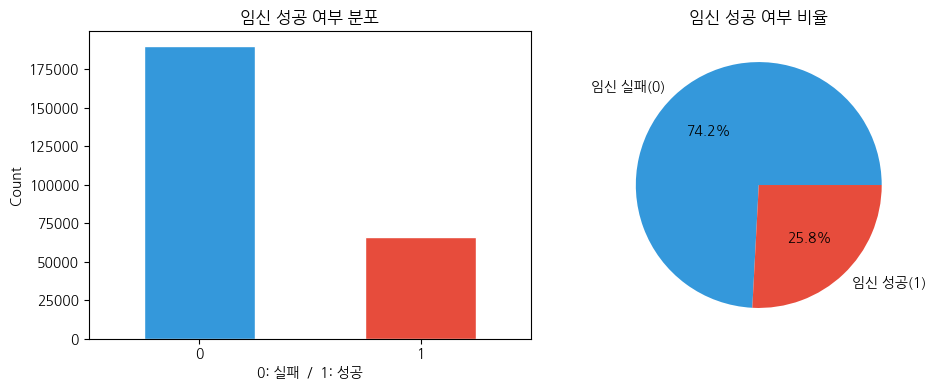

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train[TARGET].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#3498db", "#e74c3c"], edgecolor="white"
)
axes[0].set_title("임신 성공 여부 분포")
axes[0].set_xlabel("0: 실패  /  1: 성공")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

train[TARGET].value_counts().plot(
    kind="pie", ax=axes[1],
    labels=["임신 실패(0)", "임신 성공(1)"],
    autopct="%1.1f%%", colors=["#3498db", "#e74c3c"]
)
axes[1].set_title("임신 성공 여부 비율")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


  전처리 전 결측치 현황 (Train)  (결측 컬럼: 31개 / 전체: 67개)
  🔴 난자 해동 경과일                        254,915건   99.4%  float64     컬럼 제거
  🔴 PGS 시술 여부                        254,422건   99.2%  float64     컬럼 제거
  🔴 PGD 시술 여부                        254,172건   99.1%  float64     컬럼 제거
  🔴 착상 전 유전 검사 사용 여부                 253,633건   98.9%  float64     컬럼 제거
  🔴 임신 시도 또는 마지막 임신 경과 연수            246,981건   96.3%  float64     컬럼 제거
  🔴 배아 해동 경과일                        215,982건   84.3%  float64     컬럼 제거
  🟠 난자 채취 경과일                        57,488건   22.4%  float64     중앙값 대체
  🟠 난자 혼합 경과일                        53,735건   21.0%  float64     중앙값 대체
  🟡 배아 이식 경과일                        43,566건   17.0%  float64     중앙값 대체
  🟡 저장된 배아 수                          6,291건    2.5%  float64     중앙값 대체
  🟡 단일 배아 이식 여부                       6,291건    2.5%  float64     중앙값 대체
  🟡 배아 생성 주요 이유                       6,291건    2.5%  str         최빈값 대체
  🟡 착상 전 유전 진단 사용 여부                  6,291건    2.5%  float64     중앙값 대체
  🟡

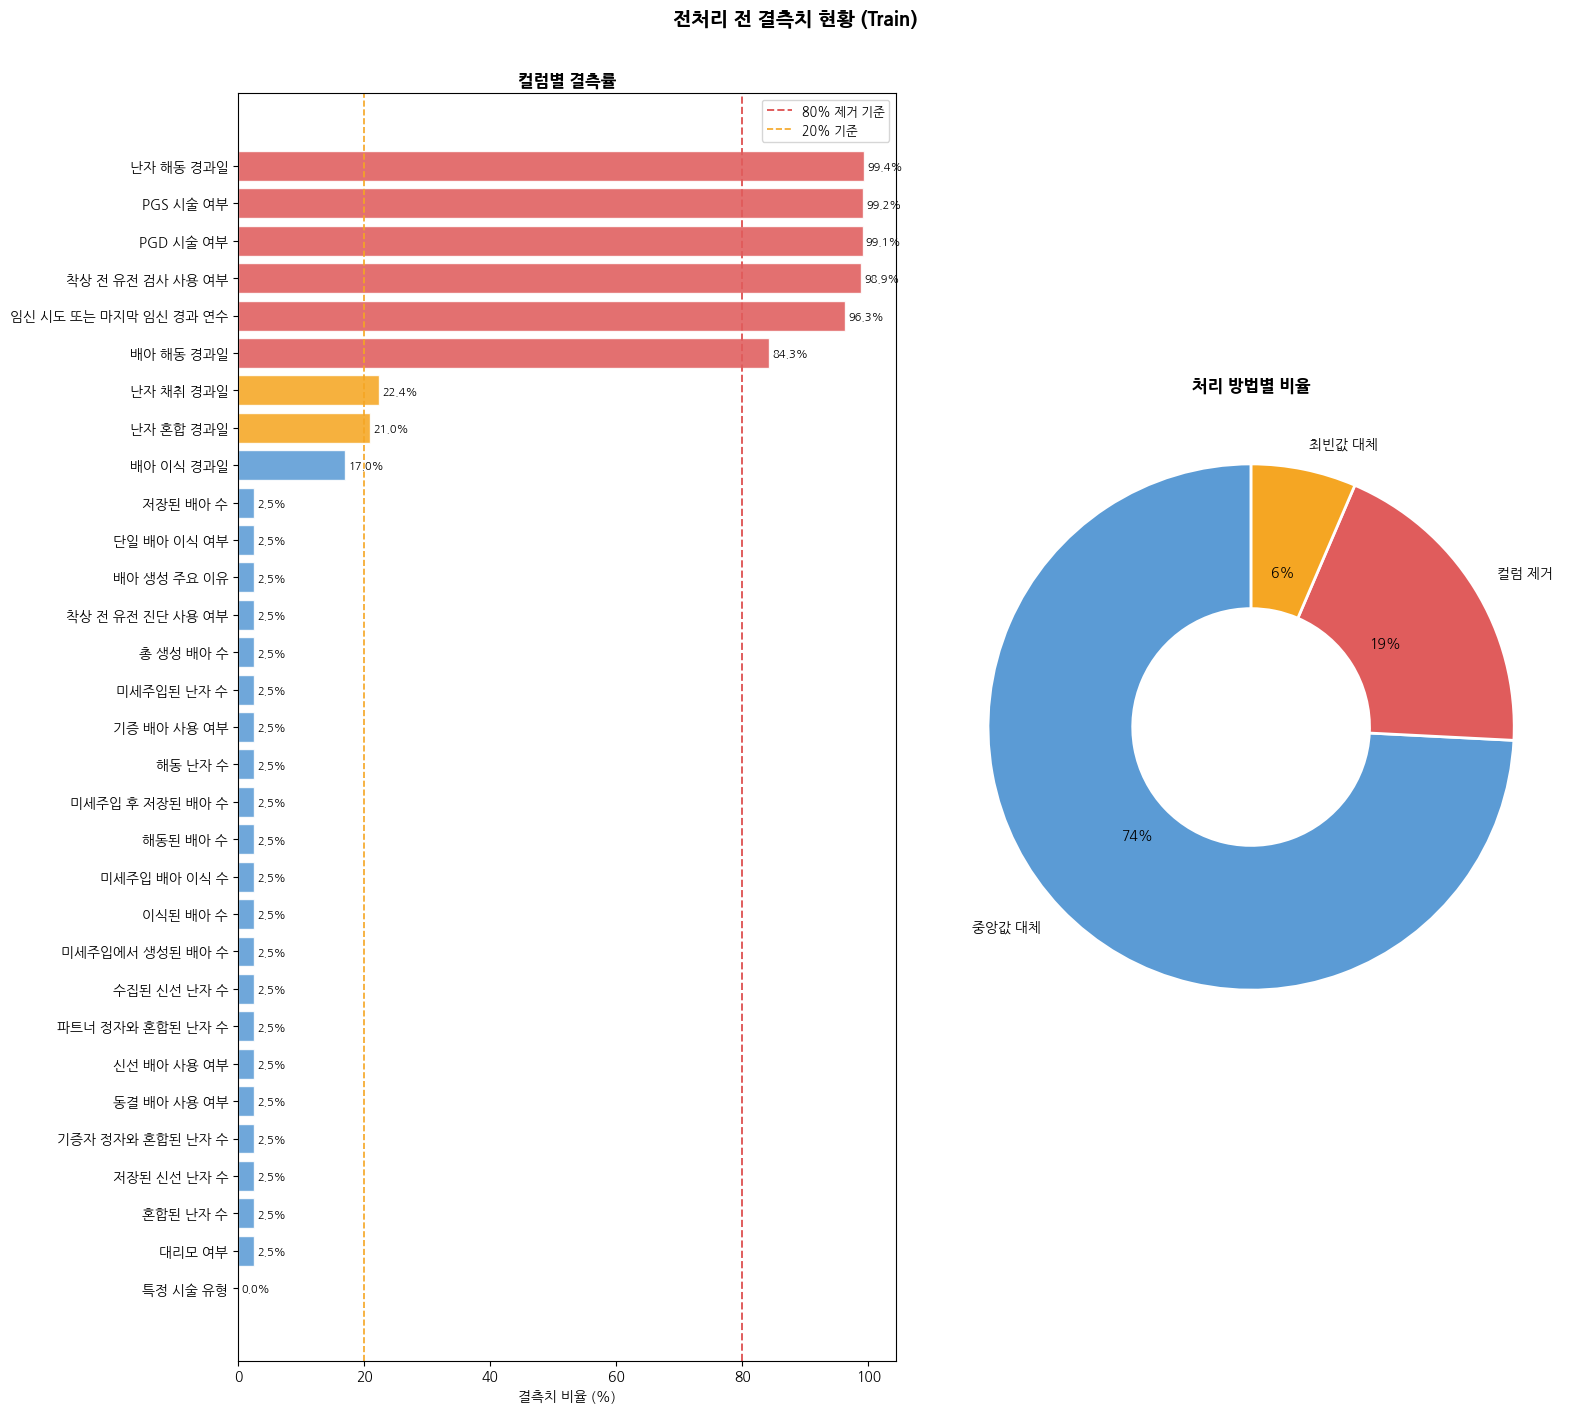

,컬럼명,결측 수,결측률(%),타입,처리 방법
0,난자 해동 경과일,254915,99.4,float64,컬럼 제거
1,PGS 시술 여부,254422,99.2,float64,컬럼 제거
2,PGD 시술 여부,254172,99.1,float64,컬럼 제거
3,착상 전 유전 검사 사용 여부,253633,98.9,float64,컬럼 제거
4,임신 시도 또는 마지막 임신 경과 연수,246981,96.3,float64,컬럼 제거
5,배아 해동 경과일,215982,84.3,float64,컬럼 제거
6,난자 채취 경과일,57488,22.4,float64,중앙값 대체
7,난자 혼합 경과일,53735,21.0,float64,중앙값 대체
8,배아 이식 경과일,43566,17.0,float64,중앙값 대체
9,저장된 배아 수,6291,2.5,float64,중앙값 대체


In [37]:
def show_missing_summary(df, title="결측치 현황"):
    missing     = df.isnull().sum()
    missing     = missing[missing > 0].sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(1)
    dtypes      = df.dtypes[missing.index].astype(str)

    def get_method(col, pct):
        if pct >= 80:
            return "컬럼 제거"
        elif col in ["난자 채취 경과일", "난자 혼합 경과일", "배아 이식 경과일"]:
            return "중앙값 대체"
        elif df[col].dtype == object:
            return "최빈값 대체"
        else:
            return "중앙값 대체" if "float" in str(df[col].dtype) else "최빈값 대체"

    methods = [get_method(col, pct) for col, pct in missing_pct.items()]

    summary = pd.DataFrame({
        "컬럼명"    : missing.index,
        "결측 수"   : missing.values,
        "결측률(%)": missing_pct.values,
        "타입"      : dtypes.values,
        "처리 방법" : methods,
    }).reset_index(drop=True)

    print(f"\n{'='*72}")
    print(f"  {title}  (결측 컬럼: {len(summary)}개 / 전체: {df.shape[1]}개)")
    print(f"{'='*72}")
    for _, row in summary.iterrows():
        flag = "🔴" if row["결측률(%)"] >= 80 else "🟠" if row["결측률(%)"] >= 20 else "🟡"
        print(f"  {flag} {row['컬럼명']:<32} {int(row['결측 수']):>6,}건  "
              f"{row['결측률(%)']:>5.1f}%  {row['타입']:<10}  {row['처리 방법']}")
    print(f"{'='*72}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(summary) * 0.45)))
    colors = ["#E05C5C" if p >= 80 else "#F5A623" if p >= 20 else "#5B9BD5"
              for p in summary["결측률(%)"]]
    axes[0].barh(summary["컬럼명"][::-1], summary["결측률(%)"][::-1],
                 color=colors[::-1], alpha=0.88, edgecolor="white")
    axes[0].axvline(80, color="#E05C5C", linestyle="--", linewidth=1.4, label="80% 제거 기준")
    axes[0].axvline(20, color="#F5A623", linestyle="--", linewidth=1.2, label="20% 기준")
    for i, val in enumerate(summary["결측률(%)"][::-1]):
        axes[0].text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=8)
    axes[0].set_xlabel("결측치 비율 (%)")
    axes[0].set_title("컬럼별 결측률", fontweight="bold")
    axes[0].legend(fontsize=9)

    method_counts = summary["처리 방법"].value_counts()
    pie_colors = {"컬럼 제거": "#E05C5C", "중앙값 대체": "#5B9BD5", "최빈값 대체": "#F5A623"}
    axes[1].pie(
        method_counts.values, labels=method_counts.index, autopct="%1.0f%%",
        colors=[pie_colors.get(m, "#AAAAAA") for m in method_counts.index],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.55},
    )
    axes[1].set_title("처리 방법별 비율", fontweight="bold")
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


# train에서 ID, 타겟 제외하고 결측 확인
show_missing_summary(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    "전처리 전 결측치 현황 (Train)"
)


  수치형 변수 이상치 현황 (IQR 기준)
                  최솟값   Q1  중앙값    Q3   최댓값  이상치 수  이상치율(%)    하한    상한
컬럼명                                                                    
총 생성 배아 수         0.0  1.0  4.0   8.0  51.0   3312      1.3  -9.5  18.5
미세주입된 난자 수        0.0  0.0  0.0   7.0  51.0   7511      3.0 -10.5  17.5
미세주입에서 생성된 배아 수   0.0  0.0  0.0   5.0  43.0   8524      3.4  -7.5  12.5
이식된 배아 수          0.0  1.0  1.0   2.0   3.0      0      0.0  -0.5   3.5
저장된 배아 수          0.0  0.0  0.0   2.0  51.0  14218      5.7  -3.0   5.0
수집된 신선 난자 수       0.0  2.0  8.0  13.0  51.0   2733      1.1 -14.5  29.5
혼합된 난자 수          0.0  3.0  7.0  11.0  51.0   5314      2.1  -9.0  23.0
파트너 정자와 혼합된 난자 수  0.0  0.0  6.0  11.0  51.0   2035      0.8 -16.5  27.5
배아 이식 경과일         0.0  2.0  3.0   5.0   7.0      0      0.0  -2.5   9.5
난자 혼합 경과일         0.0  0.0  0.0   0.0   7.0    696      0.3   0.0   0.0


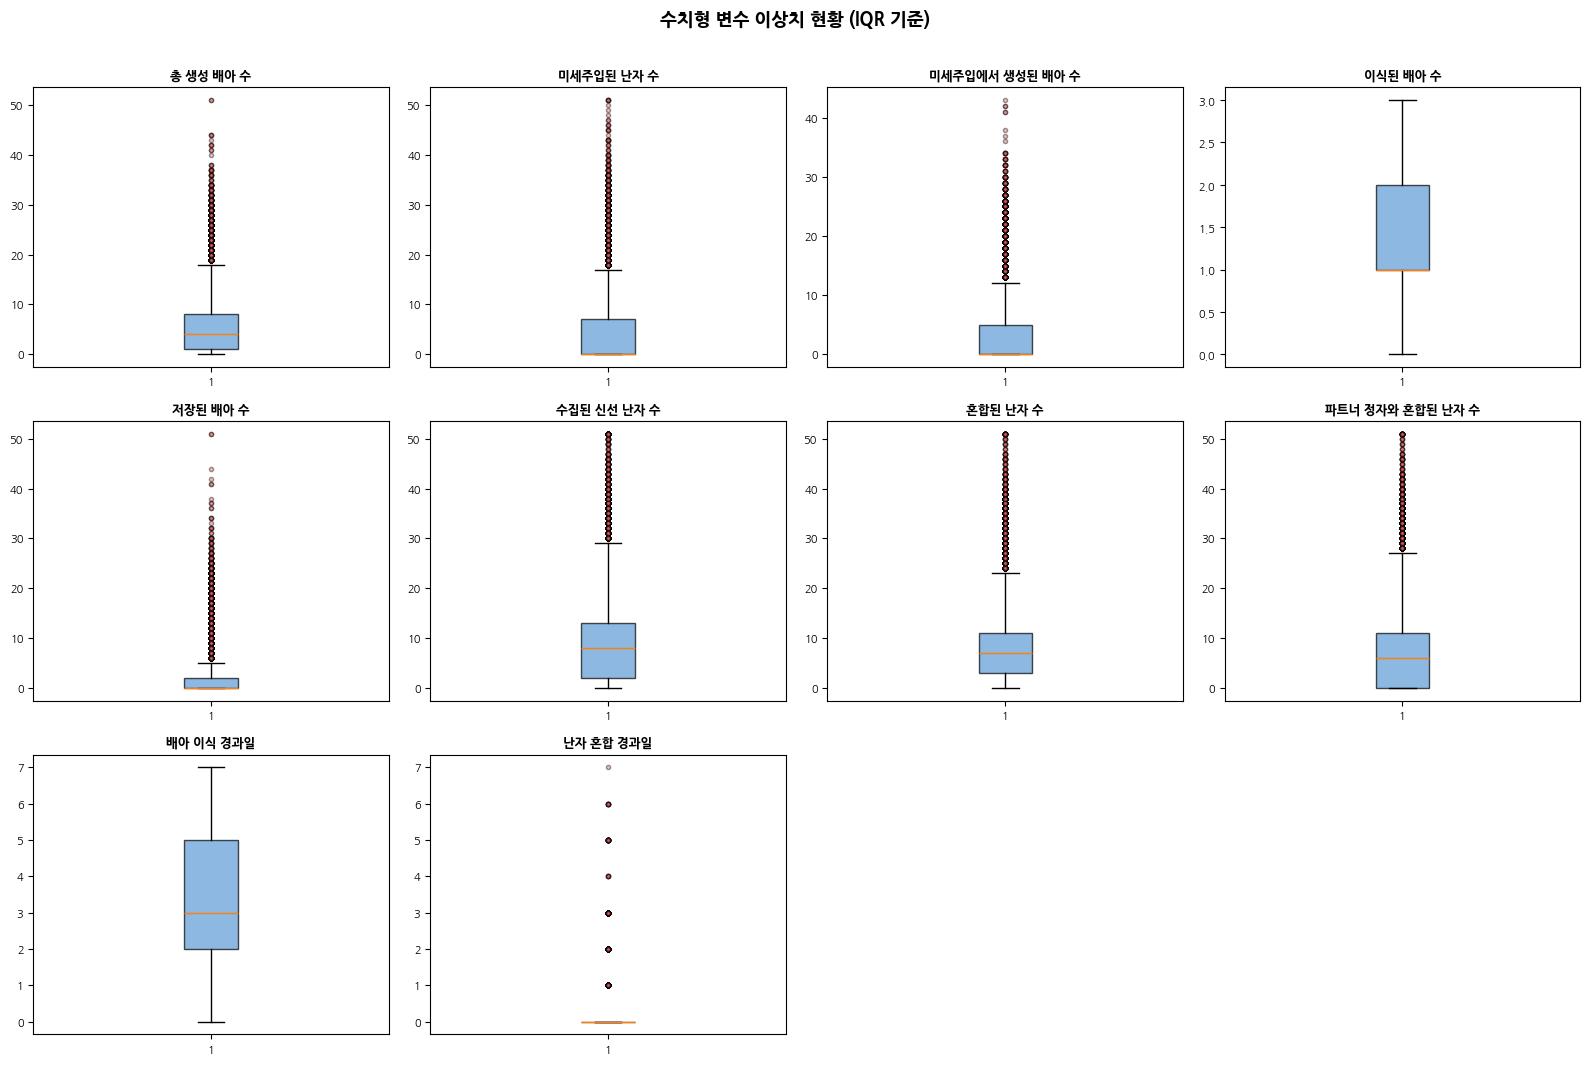

,컬럼명,최솟값,Q1,중앙값,Q3,최댓값,이상치 수,이상치율(%),하한,상한
0,총 생성 배아 수,0.0,1.0,4.0,8.0,51.0,3312,1.3,-9.5,18.5
1,미세주입된 난자 수,0.0,0.0,0.0,7.0,51.0,7511,3.0,-10.5,17.5
2,미세주입에서 생성된 배아 수,0.0,0.0,0.0,5.0,43.0,8524,3.4,-7.5,12.5
3,이식된 배아 수,0.0,1.0,1.0,2.0,3.0,0,0.0,-0.5,3.5
4,저장된 배아 수,0.0,0.0,0.0,2.0,51.0,14218,5.7,-3.0,5.0
5,수집된 신선 난자 수,0.0,2.0,8.0,13.0,51.0,2733,1.1,-14.5,29.5
6,혼합된 난자 수,0.0,3.0,7.0,11.0,51.0,5314,2.1,-9.0,23.0
7,파트너 정자와 혼합된 난자 수,0.0,0.0,6.0,11.0,51.0,2035,0.8,-16.5,27.5
8,배아 이식 경과일,0.0,2.0,3.0,5.0,7.0,0,0.0,-2.5,9.5
9,난자 혼합 경과일,0.0,0.0,0.0,0.0,7.0,696,0.3,0.0,0.0


In [38]:
def check_outliers(df, cols, title="이상치 현황 (IQR 기준)"):
    records = []
    for col in cols:
        if col not in df.columns:
            continue
        d = df[col].dropna()
        Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_cnt = ((d < lower) | (d > upper)).sum()
        records.append({
            "컬럼명"    : col,
            "최솟값"    : d.min(),  "Q1": Q1, "중앙값": d.median(),
            "Q3"        : Q3,       "최댓값": d.max(),
            "이상치 수" : out_cnt,
            "이상치율(%)": round(out_cnt / len(d) * 100, 1),
            "하한"      : round(lower, 1), "상한": round(upper, 1),
        })

    summary = pd.DataFrame(records)
    print(f"\n{'='*72}\n  {title}\n{'='*72}")
    print(summary.set_index("컬럼명").to_string())

    n_cols = 4
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()
    valid_cols = [c for c in cols if c in df.columns]
    for i, col in enumerate(valid_cols):
        data = df[col].dropna()
        bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                             flierprops=dict(marker="o", markersize=3,
                                             markerfacecolor="#E05C5C", alpha=0.4))
        bp["boxes"][0].set_facecolor("#5B9BD5")
        bp["boxes"][0].set_alpha(0.7)
        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].tick_params(labelsize=8)
    for j in range(len(valid_cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


NUM_COLS = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "이식된 배아 수", "저장된 배아 수", "수집된 신선 난자 수",
    "혼합된 난자 수", "파트너 정자와 혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
]
check_outliers(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    NUM_COLS, "수치형 변수 이상치 현황 (IQR 기준)"
)


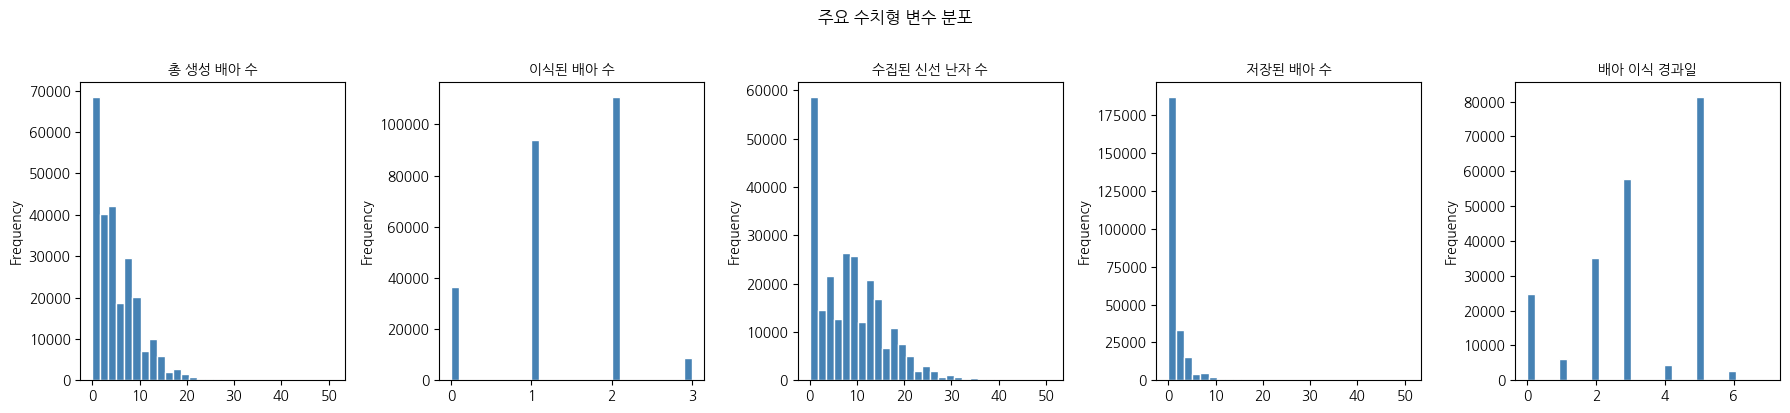

In [39]:
num_cols_view = ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
                 "저장된 배아 수", "배아 이식 경과일"]
fig, axes = plt.subplots(1, len(num_cols_view), figsize=(18, 4))
for ax, col in zip(axes, num_cols_view):
    train[col].dropna().plot(kind="hist", bins=30, ax=ax,
                             color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
plt.suptitle("주요 수치형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

In [40]:
AGE_MAP = {
    "만18-34세": 0, "만35-37세": 1, "만38-39세": 2,
    "만40-42세": 3, "만43-44세": 4, "만45-50세": 5,
    "알 수 없음": -1,
}
COUNT_MAP = {"0회": 0, "1회": 1, "2회": 2, "3회": 3, "4회": 4, "5회": 5, "6회 이상": 6}
DONOR_AGE_MAP = {
    "만20세 이하": 0, "만21-25세": 1, "만26-30세": 2,
    "만31-35세": 3,  "만36-40세": 4, "만41-45세": 5,
    "알 수 없음": -1,
}
COUNT_COLS = [
    "총 시술 횟수", "클리닉 내 총 시술 횟수",
    "IVF 시술 횟수", "DI 시술 횟수",
    "총 임신 횟수", "IVF 임신 횟수", "DI 임신 횟수",
    "총 출산 횟수", "IVF 출산 횟수", "DI 출산 횟수",
]

In [41]:
DROP_COLS = [
    "착상 전 유전 검사 사용 여부",   # 98.94% 결측, 비결측값 모두 1.0
    "PGD 시술 여부",                 # 99.15% 결측
    "PGS 시술 여부",                 # 99.25% 결측
    "불임 원인 - 여성 요인",          # zero variance
    "난자 채취 경과일",               # zero variance
    "난자 해동 경과일",               # 99.44% 결측
]

In [42]:
REASON_CATEGORIES = ["현재 시술용", "배아 저장용", "난자 저장용", "기증용", "연구용"]
PROCEDURE_TYPES   = ["IVF", "ICSI", "IUI", "ICI", "GIFT", "FER",
                     "BLASTOCYST", "AH", "Generic DI", "IVI"]

def expand_reason(df):
    col = "배아 생성 주요 이유"
    for cat in REASON_CATEGORIES:
        df[f"이유_{cat}"] = df[col].fillna("").str.contains(cat).astype(int)
    return df

def expand_procedure(df):
    col = "특정 시술 유형"
    filled = df[col].fillna("Unknown")
    for pt in PROCEDURE_TYPES:
        df[f"시술_{pt}"] = (
            filled.str.upper().str.replace(" ", "", regex=False)
            .str.contains(pt.upper()).astype(int)
        )
    return df

In [43]:
def preprocess(df: pd.DataFrame, fit_label_encoders=None) -> tuple:
    df = df.copy()

    # 컬럼 제거
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    # 임신 시도 연수 (96% 결측) → 결측 지시 변수 + -1 대체
    col_years = "임신 시도 또는 마지막 임신 경과 연수"
    if col_years in df.columns:
        df["임신_시도_연수_결측"] = df[col_years].isnull().astype(int)
        df[col_years] = df[col_years].fillna(-1)

    # 배아 해동 경과일 (84% 결측) → 결측 지시 변수 + 0 대체
    col_thaw = "배아 해동 경과일"
    if col_thaw in df.columns:
        df["배아_해동_결측"] = df[col_thaw].isnull().astype(int)
        df[col_thaw] = df[col_thaw].fillna(0)

    # DI 시술행 IVF 전용 컬럼 → 0 대체
    FILL_ZERO_COLS = [
        "단일 배아 이식 여부", "착상 전 유전 진단 사용 여부", "배아 생성 주요 이유",
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수", "저장된 배아 수",
        "미세주입 후 저장된 배아 수", "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수", "혼합된 난자 수",
        "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
        "동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부", "대리모 여부",
    ]
    for col in FILL_ZERO_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 경과일 컬럼 중앙값 대체
    for col in ["난자 혼합 경과일", "배아 이식 경과일"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # 순서형 인코딩: 나이
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(AGE_MAP).fillna(-1).astype(int)

    # 순서형 인코딩: 횟수 컬럼
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].map(COUNT_MAP).fillna(-1).astype(int)

    # 순서형 인코딩: 기증자 나이
    for col in ["난자 기증자 나이", "정자 기증자 나이"]:
        if col in df.columns:
            df[col] = df[col].map(DONOR_AGE_MAP).fillna(-1).astype(int)

    # 시술 유형 이진화 (IVF=1, DI=0)
    if "시술 유형" in df.columns:
        df["시술 유형"] = (df["시술 유형"] == "IVF").astype(int)

    # 배란 유도 유형 인코딩
    induction_map = {
        "알 수 없음": 0, "기록되지 않은 시행": 1,
        "생식선 자극 호르몬": 2, "세트로타이드 (억제제)": 3,
    }
    if "배란 유도 유형" in df.columns:
        df["배란 유도 유형"] = df["배란 유도 유형"].map(induction_map).fillna(0).astype(int)

    # 난자/정자 출처 인코딩
    egg_map   = {"본인 제공": 0, "기증 제공": 1, "알 수 없음": -1}
    sperm_map = {"배우자 제공": 0, "기증 제공": 1, "배우자 및 기증 제공": 2, "미할당": -1}
    if "난자 출처" in df.columns:
        df["난자 출처"] = df["난자 출처"].map(egg_map).fillna(-1).astype(int)
    if "정자 출처" in df.columns:
        df["정자 출처"] = df["정자 출처"].map(sperm_map).fillna(-1).astype(int)

    # 시술 시기 코드 레이블 인코딩
    code_map = {v: i for i, v in enumerate(
        ["TRCMWS", "TRDQAZ", "TRJXFG", "TRVNRY", "TRXQMD", "TRYBLT", "TRZKPL"]
    )}
    if "시술 시기 코드" in df.columns:
        df["시술 시기 코드"] = df["시술 시기 코드"].map(code_map).fillna(-1).astype(int)

    # 레이블 인코딩: 명목형 범주  ← project_1.ipynb
    LABEL_ENC_COLS = ["배아 생성 주요 이유", "특정 시술 유형"]
    label_encoders = fit_label_encoders or {}
    for col in LABEL_ENC_COLS:
        if col not in df.columns:
            continue
        if col not in label_encoders:
            le = LabelEncoder()
            le.fit(df[col].fillna("Unknown").astype(str))
            label_encoders[col] = le
        df[col] = label_encoders[col].transform(df[col].fillna("Unknown").astype(str))

    # 이진 컬럼 결측 → 0
    binary_cols = [
        "배란 자극 여부", "단일 배아 이식 여부", "착상 전 유전 진단 사용 여부",
        "남성 주 불임 원인", "남성 부 불임 원인",
        "여성 주 불임 원인", "여성 부 불임 원인",
        "부부 주 불임 원인", "부부 부 불임 원인", "불명확 불임 원인",
        "불임 원인 - 난관 질환", "불임 원인 - 남성 요인", "불임 원인 - 배란 장애",
        "불임 원인 - 자궁경부 문제", "불임 원인 - 자궁내막증",
        "불임 원인 - 정자 농도", "불임 원인 - 정자 면역학적 요인",
        "불임 원인 - 정자 운동성", "불임 원인 - 정자 형태",
        "동결 배아 사용 여부", "신선 배아 사용 여부",
        "기증 배아 사용 여부", "대리모 여부",
    ]
    for c in binary_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

    # 연속형 수치 결측 → 중앙값
    cont_cols = [
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수",
        "저장된 배아 수", "미세주입 후 저장된 배아 수",
        "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수",
        "혼합된 난자 수", "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
        "난자 혼합 경과일", "배아 이식 경과일", "배아 해동 경과일",
    ]
    for c in cont_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df[c] = df[c].fillna(df[c].median() if df[c].notna().any() else -1)

    return df, label_encoders


# 멀티레이블 분리는 전처리 전에 적용
def preprocess_full(df, fit_label_encoders=None):
    df = expand_reason(df.copy())
    df = expand_procedure(df)
    df.drop(columns=["배아 생성 주요 이유", "특정 시술 유형"],
            inplace=True, errors="ignore")
    df, le = preprocess(df, fit_label_encoders)
    return df, le


X_raw = train.drop(columns=[ID_COL, TARGET], errors="ignore")
y     = train[TARGET]
X_test_raw = test.drop(columns=[ID_COL], errors="ignore")

X_pp, label_encoders = preprocess_full(X_raw)
X_test_pp, _         = preprocess_full(X_test_raw, fit_label_encoders=label_encoders)

print(f"\n  전처리 후 Train shape: {X_pp.shape}")
print(f"  전처리 후 Test  shape: {X_test_pp.shape}")
print(f"  잔여 결측치 (Train): {X_pp.isnull().sum().sum()}")


  전처리 후 Train shape: (256351, 76)
  전처리 후 Test  shape: (90067, 76)
  잔여 결측치 (Train): 0


이변량 분석


In [44]:
AGE_ORDER   = ["만18-34세","만35-37세","만38-39세","만40-42세","만43-44세","만45-50세","알 수 없음"]
COUNT_ORDER = ["0회","1회","2회","3회","4회","5회","6회 이상"]

파생변수

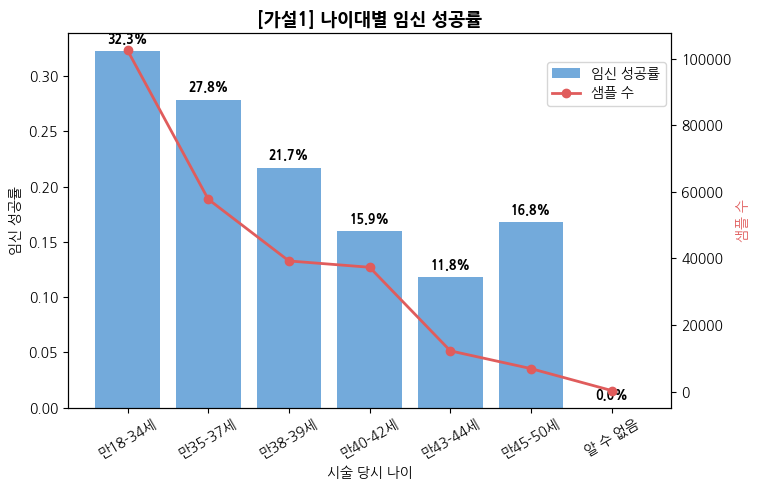

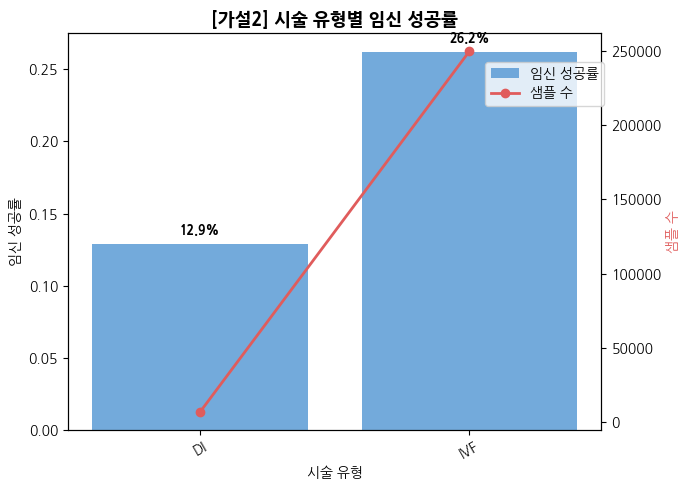

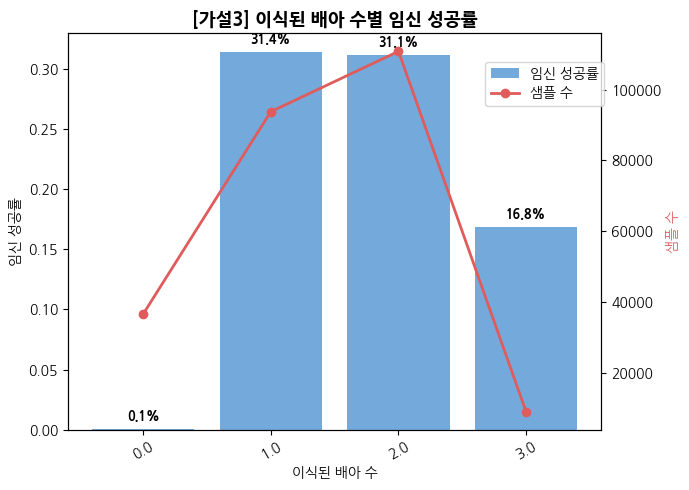

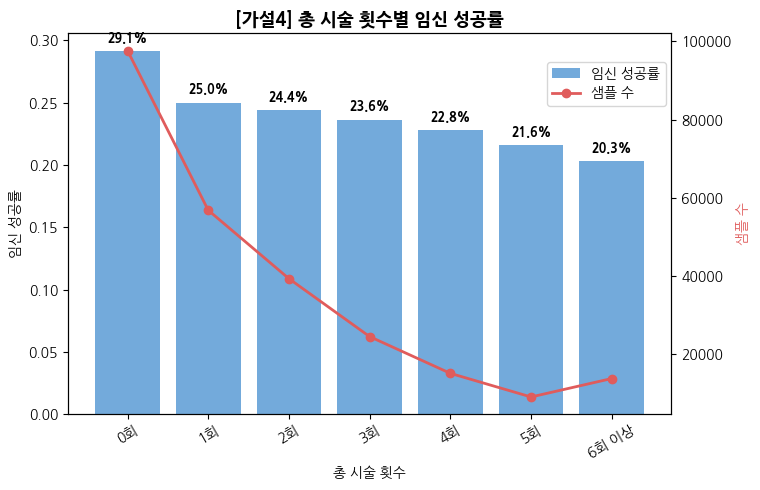

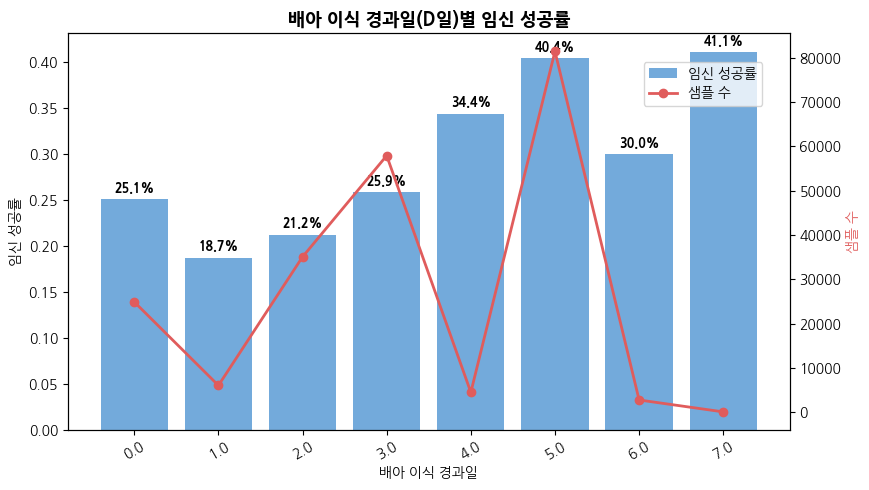

In [45]:
def plot_cat_vs_target(df, col, target, title=None, order=None):
    if col not in df.columns:
        print(f"  컬럼 없음: {col}")
        return
    grp = df.groupby(col)[target].agg(success_rate="mean", count="count").reset_index()
    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)

    fig, ax1 = plt.subplots(figsize=(max(7, len(grp) * 1.1), 5))
    ax2 = ax1.twinx()
    bars = ax1.bar(grp[col].astype(str), grp["success_rate"], color="#5B9BD5", alpha=0.85, label="임신 성공률")
    ax2.plot(grp[col].astype(str), grp["count"], color="#E05C5C", marker="o", linewidth=2, label="샘플 수")
    for bar, row in zip(bars, grp.itertuples()):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{row.success_rate:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax1.set_ylabel("임신 성공률"); ax2.set_ylabel("샘플 수", color="#E05C5C")
    ax1.set_xlabel(col); ax1.tick_params(axis="x", rotation=30)
    plt.title(title or f"{col}별 임신 성공률", fontsize=13, fontweight="bold")
    fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout(); plt.show()


# 가설 1: 나이대별 성공률
plot_cat_vs_target(df, "시술 당시 나이", TARGET, "[가설1] 나이대별 임신 성공률", AGE_ORDER)

# 가설 2: 시술 유형별 성공률
plot_cat_vs_target(df, "시술 유형", TARGET, "[가설2] 시술 유형별 임신 성공률")

# 가설 3: 이식 배아 수별 성공률
plot_cat_vs_target(df, "이식된 배아 수", TARGET, "[가설3] 이식된 배아 수별 임신 성공률")

# 가설 4: 총 시술 횟수별 성공률
plot_cat_vs_target(df, "총 시술 횟수", TARGET, "[가설4] 총 시술 횟수별 임신 성공률", COUNT_ORDER)

# 배아 이식 경과일(D일)별 성공률
plot_cat_vs_target(df, "배아 이식 경과일", TARGET, "배아 이식 경과일(D일)별 임신 성공률")

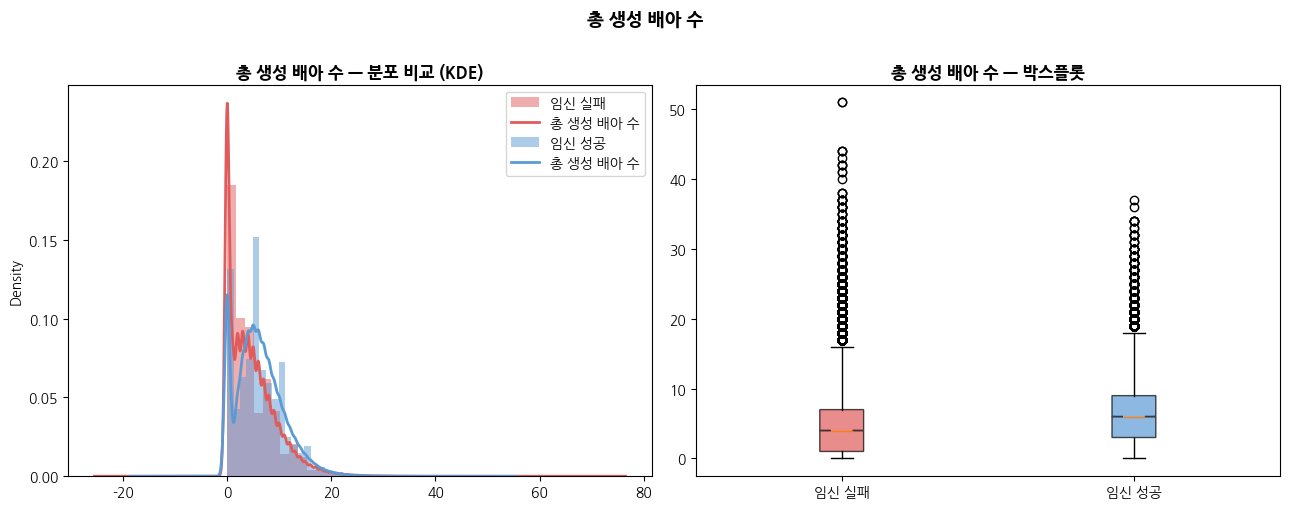

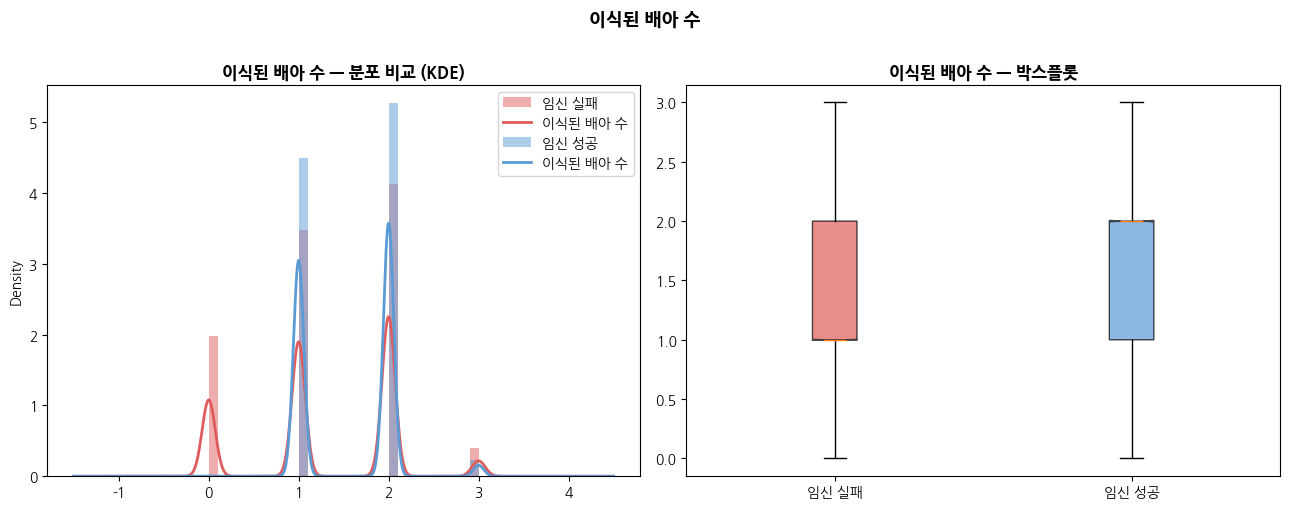

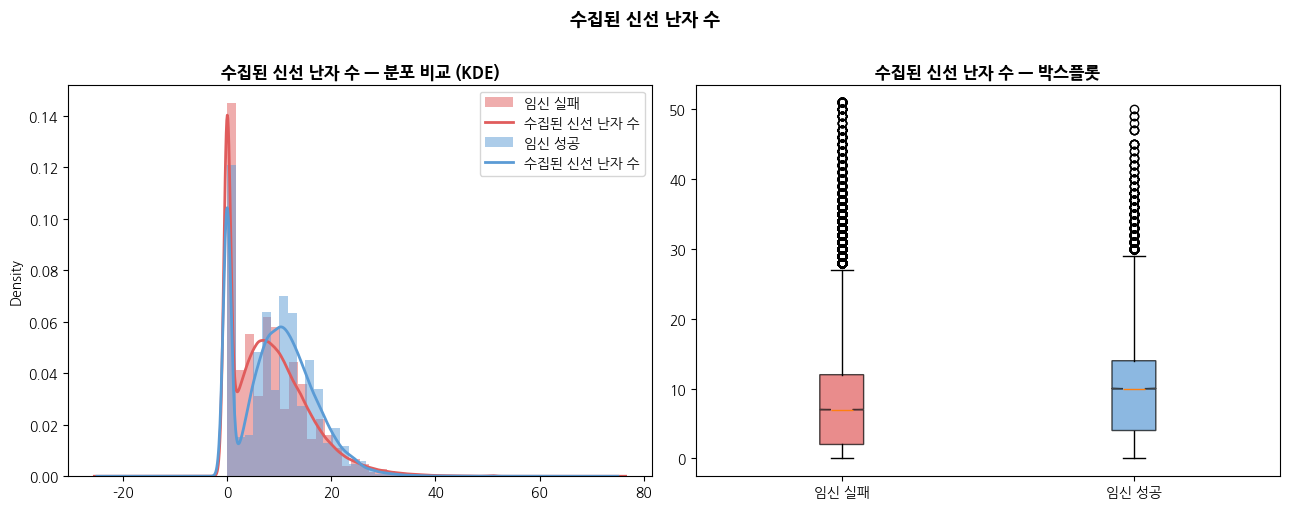

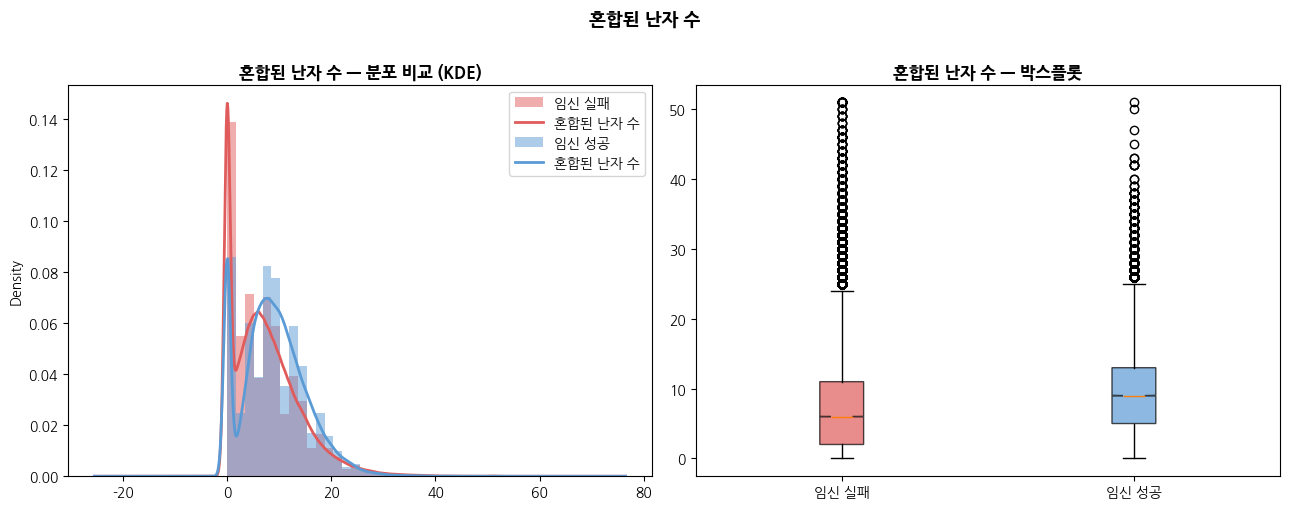

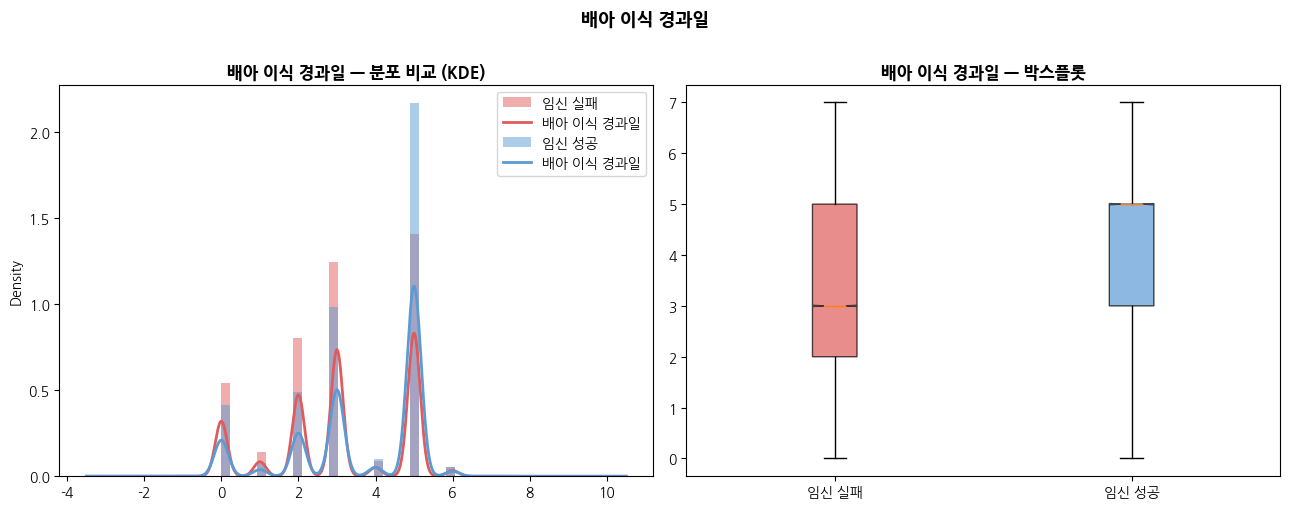

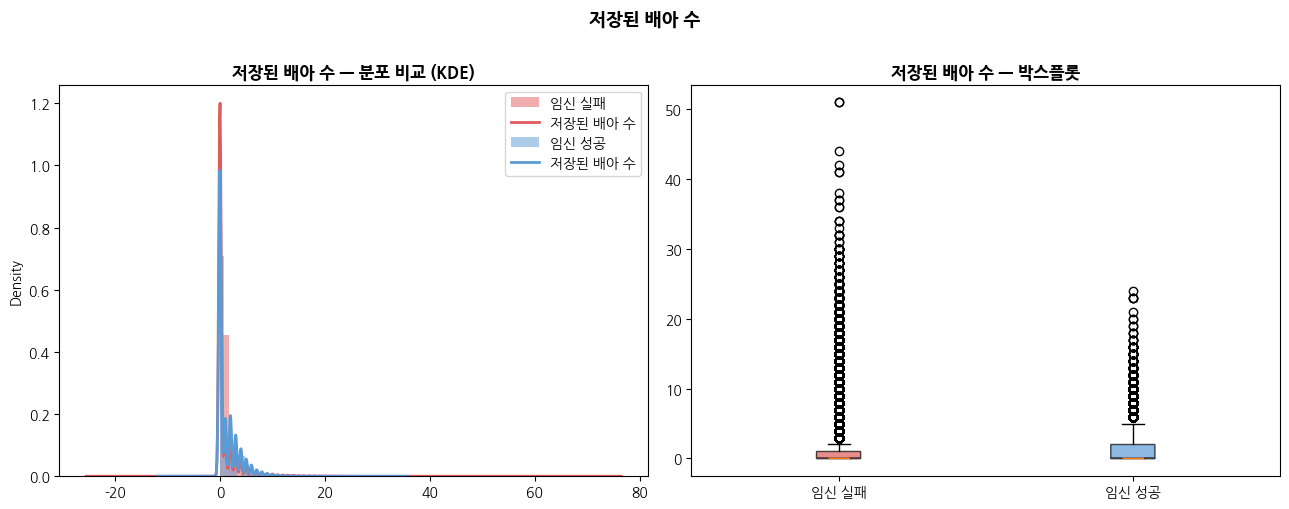

In [46]:
def plot_num_vs_target(df, col, target, title=None):
    if col not in df.columns:
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for val, label, color in [(0, "임신 실패", "#E05C5C"), (1, "임신 성공", "#5B9BD5")]:
        subset = df.loc[df[target] == val, col].dropna()
        axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
        subset.plot.kde(ax=axes[0], color=color, linewidth=2)
    axes[0].set_title(f"{col} — 분포 비교 (KDE)", fontweight="bold")
    axes[0].legend()

    bp_data = [df.loc[df[target] == 0, col].dropna(), df.loc[df[target] == 1, col].dropna()]
    bp = axes[1].boxplot(bp_data, labels=["임신 실패", "임신 성공"], patch_artist=True, notch=True)
    for patch, color in zip(bp["boxes"], ["#E05C5C", "#5B9BD5"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_title(f"{col} — 박스플롯", fontweight="bold")
    plt.suptitle(title or col, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()


for col in ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
            "혼합된 난자 수", "배아 이식 경과일", "저장된 배아 수"]:
    plot_num_vs_target(df, col, TARGET)


5. 상관관계 분석


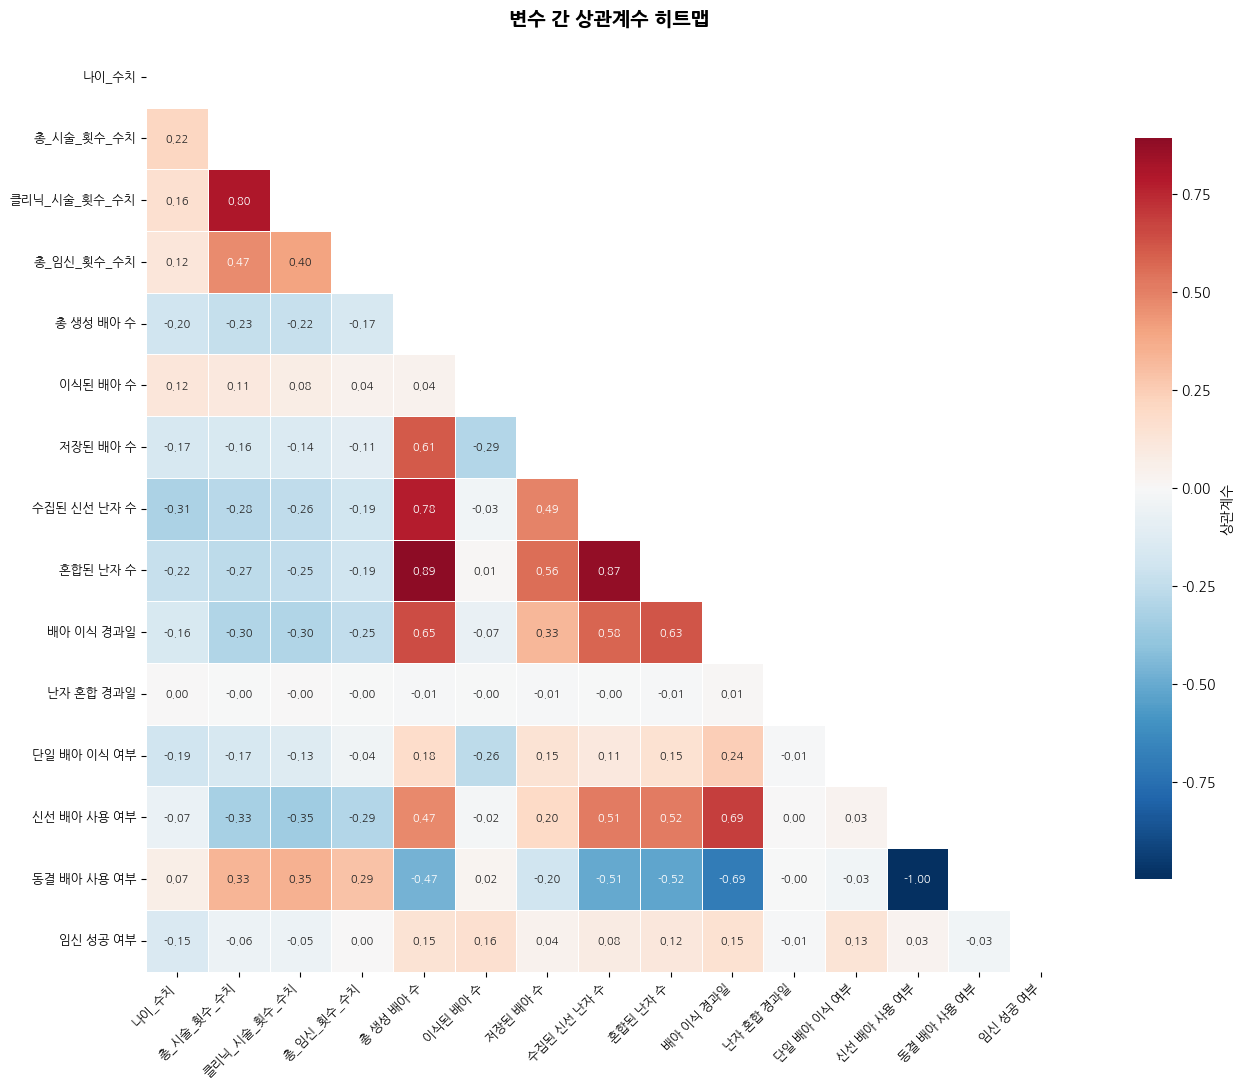

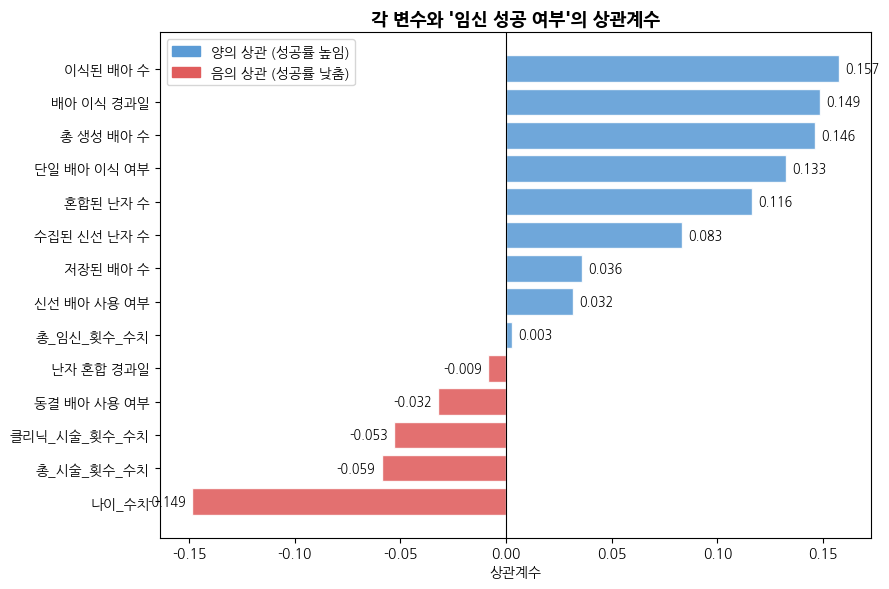


  타겟과 상관계수 TOP 10:
이식된 배아 수        0.1575
나이_수치           0.1487
배아 이식 경과일       0.1486
총 생성 배아 수       0.1461
단일 배아 이식 여부     0.1326
혼합된 난자 수        0.1161
수집된 신선 난자 수     0.0830
총_시술_횟수_수치      0.0589
클리닉_시술_횟수_수치    0.0528
저장된 배아 수        0.0360


In [47]:
print("\n" + "=" * 60)
print("5. 상관관계 분석")
print("=" * 60)

df_corr = df.copy()

# 범주형을 수치로 변환 (상관분석용)
df_corr["나이_수치"]             = df_corr["시술 당시 나이"].map(AGE_MAP)
df_corr["총_시술_횟수_수치"]     = df_corr["총 시술 횟수"].map(COUNT_MAP)
df_corr["클리닉_시술_횟수_수치"] = df_corr["클리닉 내 총 시술 횟수"].map(COUNT_MAP)
df_corr["총_임신_횟수_수치"]     = df_corr["총 임신 횟수"].map(COUNT_MAP)

CORR_COLS = [c for c in [
    "나이_수치", "총_시술_횟수_수치", "클리닉_시술_횟수_수치", "총_임신_횟수_수치",
    "총 생성 배아 수", "이식된 배아 수", "저장된 배아 수",
    "수집된 신선 난자 수", "혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
    "단일 배아 이식 여부", "신선 배아 사용 여부", "동결 배아 사용 여부",
    TARGET,
] if c in df_corr.columns]

corr_matrix = df_corr[CORR_COLS].corr()

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, square=True,
    linewidths=0.4, cbar_kws={"label": "상관계수", "shrink": 0.8},
    annot_kws={"size": 8},
)
plt.title("변수 간 상관계수 히트맵", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

# 타겟과의 상관계수 막대그래프
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values()
colors_corr = ["#E05C5C" if v < 0 else "#5B9BD5" for v in target_corr.values]
plt.figure(figsize=(9, max(6, len(target_corr) * 0.42)))
bars = plt.barh(target_corr.index, target_corr.values, color=colors_corr, alpha=0.88, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center",
             ha="left" if val >= 0 else "right", fontsize=9)
plt.xlabel("상관계수")
plt.title(f"각 변수와 '{TARGET}'의 상관계수", fontsize=13, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#5B9BD5", label="양의 상관 (성공률 높임)"),
    mpatches.Patch(color="#E05C5C", label="음의 상관 (성공률 낮춤)"),
]
plt.legend(handles=legend_patches)
plt.tight_layout(); plt.show()

print("\n  타겟과 상관계수 TOP 10:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(4).to_string())

피처 엔지니어링

In [48]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 불임 원인 개수 합산
    cause_cols = [c for c in df.columns if "불임 원인 -" in c]
    df["불임_원인_합계"] = df[cause_cols].sum(axis=1)

    # 주요 불임 원인 합계
    primary_cols = [c for c in ["남성 주 불임 원인", "여성 주 불임 원인", "부부 주 불임 원인"]
                    if c in df.columns]
    df["주요_불임_원인_합계"] = df[primary_cols].sum(axis=1)

    # 이식 효율: 이식 배아 / 생성 배아
    df["이식_효율"] = np.where(
        df["총 생성 배아 수"] > 0,
        df["이식된 배아 수"] / df["총 생성 배아 수"], 0
    )

    # ICSI 비율
    if "미세주입에서 생성된 배아 수" in df.columns:
        df["ICSI_비율"] = np.where(
            df["총 생성 배아 수"] > 0,
            df["미세주입에서 생성된 배아 수"] / df["총 생성 배아 수"], 0
        )

    # 과거 임신 성공률
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        df["과거_임신_성공률"] = np.where(
            df["총 시술 횟수"] > 0,
            df["총 임신 횟수"] / (df["총 시술 횟수"] + 1), 0
        )

    # 배아 전략 플래그 (동결=1, 기증=2, 신선=0)
    for col in ["동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부"]:
        if col not in df.columns:
            df[col] = 0
    df["배아_전략"] = (
        df["동결 배아 사용 여부"] * 1
        + df["신선 배아 사용 여부"] * 0
        + df["기증 배아 사용 여부"] * 2
    )

    # 저장 비율
    df["저장_비율"] = np.where(
        df["총 생성 배아 수"] > 0,
        df["저장된 배아 수"] / df["총 생성 배아 수"], 0
    )

    # 기증 사용 플래그
    df["기증_사용"] = (
        (df.get("난자 출처", pd.Series(0, index=df.index)) == 1)
        | (df.get("정자 출처", pd.Series(0, index=df.index)) == 1)
    ).astype(int)

      # 동결배아 활용률: 실제 해동 사용 / 저장 총수
    #   → 높을수록 보관 배아를 적극 활용한 주기
    if "해동된 배아 수" in df.columns:
        df["동결배아_활용률"] = np.where(
            df["저장된 배아 수"] > 0,
            df["해동된 배아 수"] / df["저장된 배아 수"], 0
        )

    # ICSI 후 동결된 배아 비율: ICSI 저장 / 이식 배아
    #   → 미세주입 배아 중 실제 이식 외 저장된 비중
    if "미세주입 후 저장된 배아 수" in df.columns:
        df["ICSI동결_이식비율"] = np.where(
            df["이식된 배아 수"] > 0,
            df["미세주입 후 저장된 배아 수"] / df["이식된 배아 수"], 0
        )

    # 순수 동결 주기 플래그: 동결=1 & 신선=0
    #   → 신선 배아 없이 동결만 사용한 주기 (FER 주기)
    df["순수동결_주기"] = (
        (df["동결 배아 사용 여부"] == 1) & (df["신선 배아 사용 여부"] == 0)
    ).astype(int)

    # 동결 잉여율: (저장 - 해동) / 저장
    #   → 아직 남아있는 동결 배아 비율 (낮을수록 소진됨)
    if "해동된 배아 수" in df.columns:
        remaining = (df["저장된 배아 수"] - df["해동된 배아 수"]).clip(lower=0)
        df["동결배아_잉여율"] = np.where(
            df["저장된 배아 수"] > 0,
            remaining / df["저장된 배아 수"], 0
        )

    # 동결 배아 총량 지수: 저장 + 해동 (해동 포함 시)
    #   → 누적 동결 배아 규모를 반영
    if "해동된 배아 수" in df.columns:
        df["동결배아_총량"] = df["저장된 배아 수"] + df["해동된 배아 수"]
    # 전처리 후 "시술 당시 나이"는 순서형 정수 0~5 (-1=알 수 없음)
    # "수집된 신선 난자 수"는 연속형 수치

    if "수집된 신선 난자 수" in df.columns and "시술 당시 나이" in df.columns:
        age_num = df["시술 당시 나이"].replace(-1, np.nan)  # 알 수 없음 → NaN
        egg_cnt = df["수집된 신선 난자 수"]

        # 나이 × 난자 수 교호작용항
        #   → 나이 코드가 높고 난자도 많은 경우 큰 값 (고령 고수확)
        df["나이x난자수"] = (age_num * egg_cnt).fillna(0)

        # 나이 보정 난자 효율: 난자 수 / (나이 코드 + 1)
        #   → 같은 난자 수라도 나이가 낮을수록 효율이 높음을 표현
        df["나이보정_난자효율"] = (egg_cnt / (age_num.fillna(0) + 1))

        # 혼합 난자 대비 수정 효율: 총 배아 / 혼합 난자
        #   → 난자 수정 성공률 근사
        if "혼합된 난자 수" in df.columns:
            df["수정_효율"] = np.where(
                df["혼합된 난자 수"] > 0,
                df["총 생성 배아 수"] / df["혼합된 난자 수"], 0
            )

        # 고령 저반응 플래그: 나이 >= 3 (만40-42세+) AND 난자 수 < 중앙값
        #   → 고령임에도 채취 수가 낮은 불량 예후 케이스
        egg_median = egg_cnt.median()
        df["고령저반응"] = (
            (age_num >= 3) & (egg_cnt < egg_median)
        ).fillna(False).astype(int)

        # 젊고 고수확 플래그: 나이 <= 1 (만18-37세) AND 난자 수 >= 75th 백분위
        egg_q75 = egg_cnt.quantile(0.75)
        df["젊고고수확"] = (
            (age_num <= 1) & (egg_cnt >= egg_q75)
        ).fillna(False).astype(int)
      # 배아 손실 수: 생성 - 이식 - 저장 (폐기된 배아 추정)
    #   → 낮을수록 배아 관리 효율이 좋음
    df["배아_손실수"] = (
        df["총 생성 배아 수"]
        - df["이식된 배아 수"]
        - df["저장된 배아 수"]
    ).clip(lower=0)

    # 배아 총 활용률: (이식 + 저장) / 생성
    #   → 1에 가까울수록 생성 배아를 모두 활용
    df["배아_총활용률"] = np.where(
        df["총 생성 배아 수"] > 0,
        (df["이식된 배아 수"] + df["저장된 배아 수"]) / df["총 생성 배아 수"], 0
    ).clip(0, 1)

    # 배아 풍요도 구간: 0=없음, 1=적음(1-3), 2=보통(4-7), 3=많음(8+)
    embryo_max = max(df["총 생성 배아 수"].max() + 1, 9)
    df["배아_풍요도"] = pd.cut(
        df["총 생성 배아 수"],
        bins=[-1, 0, 3, 7, embryo_max],
        labels=[0, 1, 2, 3]
    ).astype(float).fillna(0).astype(int)

    # 다배아 이식 플래그: 이식 배아 >= 3 (다태 임신 위험 기준)
    df["다배아이식_플래그"] = (df["이식된 배아 수"] >= 3).astype(int)

    # 배아 품질 복합 지수: 이식 효율 × 배아 총 활용률
    #   → 두 효율 지표를 동시에 고려한 종합 배아 품질 점수 (0~1)
    df["배아품질_복합지수"] = df["이식_효율"] * df["배아_총활용률"]

    # ICSI 배아 우위 비율: ICSI 배아 / 총 배아
    #   → 미세주입 의존도. 높을수록 정자 문제 가능성
    if "미세주입에서 생성된 배아 수" in df.columns:
        df["ICSI배아_우위비율"] = np.where(
            df["총 생성 배아 수"] > 0,
            df["미세주입에서 생성된 배아 수"] / df["총 생성 배아 수"], 0
        )

    # 이식 집중도: 이식 배아 / (이식 + 저장)
    #   → 보관보다 즉시 이식에 집중한 정도
    denom_43 = df["이식된 배아 수"] + df["저장된 배아 수"]
    df["이식_집중도"] = np.where(denom_43 > 0, df["이식된 배아 수"] / denom_43, 0)

    if "시술 유형" in df.columns and "시술 당시 나이" in df.columns:
        age_num2 = df["시술 당시 나이"].replace(-1, 0)  # 알 수 없음 → 0

        # 나이 × 시술 유형 교호작용항
        #   → IVF 시술 + 나이가 높을수록 큰 값. IVF의 나이 의존성 포착
        df["나이x시술유형"] = age_num2 * df["시술 유형"]

        # 고령 IVF 플래그: 나이 >= 3 (만40+) AND IVF 시술
        #   → 고령에서 IVF를 선택한 고위험 케이스
        df["고령IVF"] = (
            (df["시술 당시 나이"] >= 3) & (df["시술 유형"] == 1)
        ).astype(int)

        # 젊은 DI 플래그: 나이 <= 1 (만18-37세) AND DI 시술
        #   → 상대적으로 단순 시술로도 기대치가 높은 케이스
        df["젊은DI"] = (
            (df["시술 당시 나이"] <= 1) & (df["시술 유형"] == 0)
        ).astype(int)

        # 나이 구간별 시술 유형 복합 코드: age_band * 10 + procedure_type
        #   → 나이-시술 조합을 단일 범주로 표현 (트리 모델에서 분기 포착)
        df["나이_시술_복합코드"] = df["시술 당시 나이"].clip(lower=0) * 10 + df["시술 유형"]

    if "총 시술 횟수" in df.columns and "시술 당시 나이" in df.columns:
        age_num3  = df["시술 당시 나이"].replace(-1, 0)
        trial_num = df["총 시술 횟수"].replace(-1, 0)

        # 나이 × 총 시술 횟수 교호작용항
        #   → 나이가 많고 시술 횟수가 많을수록 큰 값 (반복 실패 + 고령)
        df["나이x총시술횟수"] = age_num3 * trial_num

        # 클리닉 내 시술 횟수 교호작용 (동일 클리닉 내 축적 경험)
        if "클리닉 내 총 시술 횟수" in df.columns:
            clinic_num = df["클리닉 내 총 시술 횟수"].replace(-1, 0)
            df["나이x클리닉시술횟수"] = age_num3 * clinic_num

        # IVF 전용 시술 횟수 × 나이
        if "IVF 시술 횟수" in df.columns:
            ivf_num = df["IVF 시술 횟수"].replace(-1, 0)
            df["나이xIVF횟수"] = age_num3 * ivf_num

        # 고령 반복 시술 플래그: 나이 >= 3 AND 총 시술 횟수 >= 3
        #   → 고령 + 반복 실패 이력의 복합 고위험군
        df["고령반복시술"] = (
            (df["시술 당시 나이"] >= 3) & (trial_num >= 3)
        ).astype(int)

        # 시술 누적 부담 지수: 나이 × (총 시술 + IVF 시술) / 2
        #   → 나이와 시술 이력을 결합한 누적 부담 점수
        if "IVF 시술 횟수" in df.columns:
            ivf_num = df["IVF 시술 횟수"].replace(-1, 0)
            df["시술부담_지수"] = age_num3 * (trial_num + ivf_num) / 2

    print(f"  피처 수: {df.shape[1]}개")
    return df

X_train = feature_engineering(X_pp)
X_test  = feature_engineering(X_test_pp)

  피처 수: 110개
  피처 수: 110개


In [49]:
common_cols = [c for c in X_train.columns if c in X_test.columns]
X_train = X_train[common_cols]
X_test  = X_test[common_cols]

print(f"  최종 Train 피처: {X_train.shape[1]}개")
print(f"  최종 Test  피처: {X_test.shape[1]}개")

  최종 Train 피처: 110개
  최종 Test  피처: 110개


모델 학습

In [50]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros(len(X_train))
oof_xgb  = np.zeros(len(X_train))
oof_cat  = np.zeros(len(X_train))
pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

In [51]:
# ============================================================
# 7. LightGBM 단독 모델 학습 (5-Fold Stratified CV)
# ============================================================
print("\n" + "=" * 60)
print("7. LightGBM 단독 모델 학습 (5-Fold Stratified CV)")
print("=" * 60)

N_SPLITS = 5
SEED     = 42
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred  = np.zeros(len(X_train))   # OOF 예측 확률
test_pred = np.zeros(len(X_test))    # 테스트 예측 확률 (폴드 평균)
fold_aucs = []                        # 폴드별 AUC 기록
lgb_models = []                       # 폴드별 학습된 lgb 모델 보관

lgb_params = {
    "objective":         "binary",
    "metric":            "auc",
    "learning_rate":     0.05,
    "num_leaves":        127,
    "max_depth":         -1,
    "min_child_samples": 20,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "reg_alpha":         0.1,
    "reg_lambda":        0.1,
    "n_jobs":            -1,
    "seed":              SEED,
    "verbose":           -1,
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=500),
        ],
    )

    oof_pred[val_idx]  = model.predict(X_val)
    oof_lgb[val_idx]  = oof_pred[val_idx]
    test_pred         += model.predict(X_test) / N_SPLITS
    pred_lgb          += model.predict(X_test) / N_SPLITS
    fold_auc           = roc_auc_score(y_val, oof_pred[val_idx])
    fold_aucs.append(fold_auc)
    lgb_models.append(model)

    print(f"  Fold {fold+1}  |  best iter: {model.best_iteration:>4}  |  AUC: {fold_auc:.4f}")

oof_auc = roc_auc_score(y, oof_pred)
print(f"\n  ── 폴드별 AUC: {[round(a, 4) for a in fold_aucs]}")
print(f"  ── AUC 평균 ± 표준편차: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  ★ OOF AUC (전체): {oof_auc:.4f}")


7. LightGBM 단독 모델 학습 (5-Fold Stratified CV)
  Fold 1  |  best iter:   63  |  AUC: 0.7359
  Fold 2  |  best iter:  105  |  AUC: 0.7416
  Fold 3  |  best iter:   67  |  AUC: 0.7391
  Fold 4  |  best iter:   59  |  AUC: 0.7371
  Fold 5  |  best iter:   75  |  AUC: 0.7386

  ── 폴드별 AUC: [0.7359, 0.7416, 0.7391, 0.7371, 0.7386]
  ── AUC 평균 ± 표준편차: 0.7385 ± 0.0019
  ★ OOF AUC (전체): 0.7384


In [52]:
# ============================================================
# 7. XGBoost 단독 모델 학습 (5-Fold Stratified CV)
# ============================================================
print("\n" + "=" * 60)
print("7. XGBoost 단독 모델 학습 (5-Fold Stratified CV)")
print("=" * 60)

N_SPLITS = 5
SEED     = 42
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred  = np.zeros(len(X_train))
test_pred = np.zeros(len(X_test))
fold_aucs = []
models    = []

xgb_params = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "learning_rate":    0.05,
    "max_depth":        6,
    "min_child_weight": 5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "gamma":            0.1,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
    "seed":             SEED,
    "n_jobs":           -1,
    "tree_method":      "hist",
    "verbosity":        0,
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=list(X_train.columns))
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=list(X_train.columns))

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=2000,
        evals=[(dval, "val")],
        early_stopping_rounds=100,
        verbose_eval=500,
    )

    oof_pred[val_idx]  = model.predict(dval)
    test_pred         += model.predict(
        xgb.DMatrix(X_test, feature_names=list(X_train.columns))
    ) / N_SPLITS
    fold_auc           = roc_auc_score(y_val, oof_pred[val_idx])
    fold_aucs.append(fold_auc)
    models.append(model)

    print(f"  Fold {fold+1}  |  best iter: {model.best_iteration:>4}  |  AUC: {fold_auc:.4f}")

oof_auc = roc_auc_score(y, oof_pred)
print(f"\n  ── 폴드별 AUC: {[round(a, 4) for a in fold_aucs]}")
print(f"  ── AUC 평균 ± 표준편차: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  ★ OOF AUC (전체): {oof_auc:.4f}")



7. XGBoost 단독 모델 학습 (5-Fold Stratified CV)
[0]	val-auc:0.72528
[240]	val-auc:0.73673
  Fold 1  |  best iter:  140  |  AUC: 0.7367
[0]	val-auc:0.72816
[363]	val-auc:0.74215
  Fold 2  |  best iter:  263  |  AUC: 0.7421
[0]	val-auc:0.72649
[272]	val-auc:0.73970
  Fold 3  |  best iter:  172  |  AUC: 0.7397
[0]	val-auc:0.72647
[251]	val-auc:0.73734
  Fold 4  |  best iter:  151  |  AUC: 0.7373
[0]	val-auc:0.72421
[278]	val-auc:0.73967
  Fold 5  |  best iter:  178  |  AUC: 0.7397

  ── 폴드별 AUC: [0.7367, 0.7421, 0.7397, 0.7373, 0.7397]
  ── AUC 평균 ± 표준편차: 0.7391 ± 0.0019
  ★ OOF AUC (전체): 0.7391


In [53]:
# ============================================================
# 7. CatBoost 단독 모델 학습 (5-Fold Stratified CV)
# ============================================================
print("\n" + "=" * 60)
print("7. CatBoost 단독 모델 학습 (5-Fold Stratified CV)")
print("=" * 60)

N_SPLITS = 5
SEED     = 42
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred  = np.zeros(len(X_train))
test_pred = np.zeros(len(X_test))
fold_aucs = []
cat_models = []

cat_params = {
    "iterations":          2000,
    "learning_rate":       0.05,
    "depth":               6,
    "l2_leaf_reg":         3,
    "eval_metric":         "AUC",
    "early_stopping_rounds": 100,
    "random_seed":         SEED,
    "verbose":             500,
    "task_type":           "CPU",
    "bootstrap_type":      "Bernoulli",
    "subsample":           0.8,
    "colsample_bylevel":   0.8,
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    oof_pred[val_idx]  = model.predict_proba(X_val)[:, 1]
    oof_cat[val_idx]  = oof_pred[val_idx]
    test_pred         += model.predict_proba(X_test)[:, 1] / N_SPLITS
    pred_cat          += model.predict_proba(X_test)[:, 1] / N_SPLITS
    fold_auc           = roc_auc_score(y_val, oof_pred[val_idx])
    fold_aucs.append(fold_auc)
    cat_models.append(model)

    print(f"  Fold {fold+1}  |  best iter: {model.best_iteration_:>4}  |  AUC: {fold_auc:.4f}")

oof_auc = roc_auc_score(y, oof_pred)
print(f"\n  ── 폴드별 AUC: {[round(a, 4) for a in fold_aucs]}")
print(f"  ── AUC 평균 ± 표준편차: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  ★ OOF AUC (전체): {oof_auc:.4f}")


7. CatBoost 단독 모델 학습 (5-Fold Stratified CV)
0:	test: 0.7078795	best: 0.7078795 (0)	total: 42.2ms	remaining: 1m 24s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7376803606
bestIteration = 363

Shrink model to first 364 iterations.
  Fold 1  |  best iter:  363  |  AUC: 0.7377
0:	test: 0.7184765	best: 0.7184765 (0)	total: 37.5ms	remaining: 1m 14s
500:	test: 0.7432611	best: 0.7433537 (473)	total: 18.1s	remaining: 54.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7433537432
bestIteration = 473

Shrink model to first 474 iterations.
  Fold 2  |  best iter:  473  |  AUC: 0.7434
0:	test: 0.7160275	best: 0.7160275 (0)	total: 35.8ms	remaining: 1m 11s
500:	test: 0.7394135	best: 0.7394185 (497)	total: 18.2s	remaining: 54.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7394535107
bestIteration = 530

Shrink model to first 531 iterations.
  Fold 3  |  best iter:  530  |  AUC: 0.7395
0:	test: 0.7088054	best: 0.7088054 (0)	total

In [54]:
submission = pd.DataFrame({
    "ID": test[ID_COL],
    "probability": test_pred
})

submission.to_csv("submission.csv", index=False)

## CatBoost × LightGBM 앙상블


8. CatBoost × LightGBM 앙상블 평가
  LightGBM  OOF AUC: 0.7384
  CatBoost  OOF AUC: 0.7398

  최적 가중치  →  LightGBM: 0.25  /  CatBoost: 0.75
  앙상블 OOF AUC (최적): 0.7400
  단순 평균 OOF AUC    : 0.7398


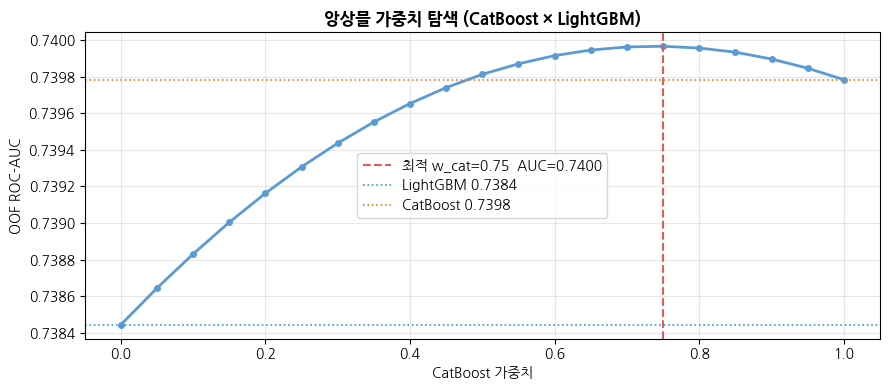

In [55]:
# ============================================================
# 8. CatBoost × LightGBM 앙상블  (가중 평균)
# ============================================================
print('\n' + '=' * 60)
print('8. CatBoost × LightGBM 앙상블 평가')
print('=' * 60)

auc_lgb = roc_auc_score(y, oof_lgb)
auc_cat = roc_auc_score(y, oof_cat)
print(f'  LightGBM  OOF AUC: {auc_lgb:.4f}')
print(f'  CatBoost  OOF AUC: {auc_cat:.4f}')

weights = np.arange(0.0, 1.05, 0.05)
blend_aucs = []
for w_cat in weights:
    w_lgb = 1.0 - w_cat
    oof_blend = w_lgb * oof_lgb + w_cat * oof_cat
    blend_aucs.append(roc_auc_score(y, oof_blend))

best_w_cat = weights[np.argmax(blend_aucs)]
best_w_lgb = 1.0 - best_w_cat
best_auc   = max(blend_aucs)

print(f'\n  최적 가중치  →  LightGBM: {best_w_lgb:.2f}  /  CatBoost: {best_w_cat:.2f}')
print(f'  앙상블 OOF AUC (최적): {best_auc:.4f}')
print(f'  단순 평균 OOF AUC    : {roc_auc_score(y, 0.5*oof_lgb + 0.5*oof_cat):.4f}')

plt.figure(figsize=(9, 4))
plt.plot(weights, blend_aucs, marker='o', markersize=4, color='#5B9BD5', linewidth=2)
plt.axvline(best_w_cat, color='#E05C5C', linestyle='--', linewidth=1.5,
            label=f'최적 w_cat={best_w_cat:.2f}  AUC={best_auc:.4f}')
plt.axhline(auc_lgb, color='#3498db', linestyle=':', linewidth=1.2, label=f'LightGBM {auc_lgb:.4f}')
plt.axhline(auc_cat, color='#e67e22', linestyle=':', linewidth=1.2, label=f'CatBoost {auc_cat:.4f}')
plt.xlabel('CatBoost 가중치')
plt.ylabel('OOF ROC-AUC')
plt.title('앙상블 가중치 탐색 (CatBoost × LightGBM)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


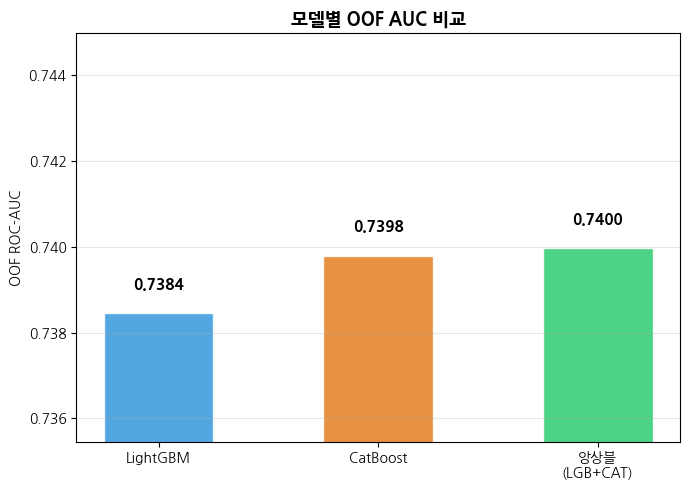


  [AUC 향상]
  앙상블 vs LightGBM : +0.0015
  앙상블 vs CatBoost : +0.0002


In [56]:
model_names  = ['LightGBM', 'CatBoost', '앙상블\n(LGB+CAT)']
model_aucs   = [auc_lgb, auc_cat, best_auc]
bar_colors   = ['#3498db', '#e67e22', '#2ecc71']

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, model_aucs, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, auc in zip(bars, model_aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{auc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(min(model_aucs) - 0.003, max(model_aucs) + 0.005)
plt.ylabel('OOF ROC-AUC')
plt.title('모델별 OOF AUC 비교', fontweight='bold', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n  [AUC 향상]')
print(f'  앙상블 vs LightGBM : +{best_auc - auc_lgb:.4f}')
print(f'  앙상블 vs CatBoost : +{best_auc - auc_cat:.4f}')


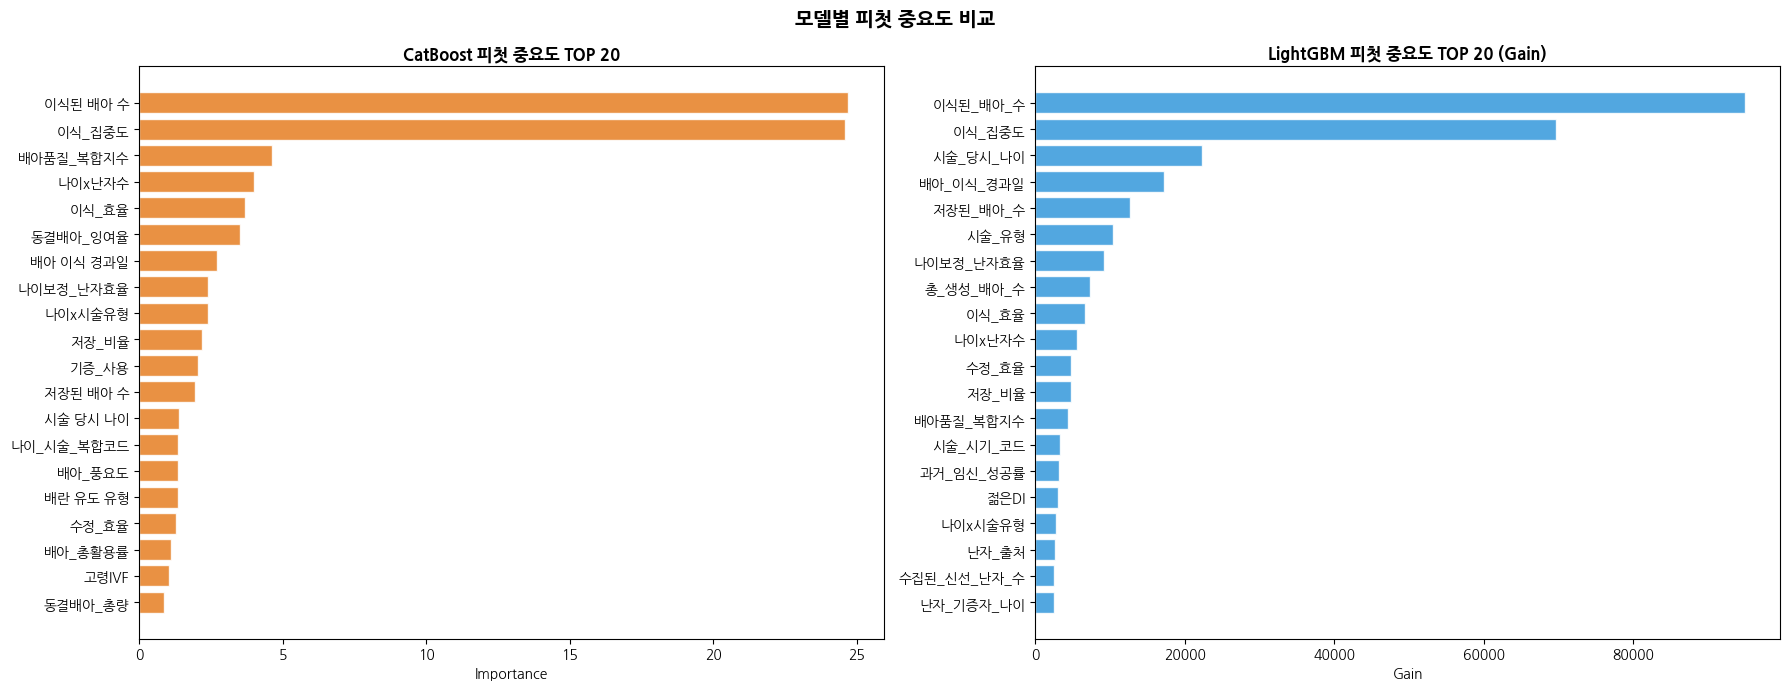

In [57]:
import warnings; warnings.filterwarnings('ignore')

cat_models_list = cat_models

cat_fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.mean([m.get_feature_importance() for m in cat_models_list], axis=0)
}).sort_values('importance', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(cat_fi_df['feature'][::-1], cat_fi_df['importance'][::-1],
             color='#e67e22', alpha=0.85, edgecolor='white')
axes[0].set_title('CatBoost 피첫 중요도 TOP 20', fontweight='bold')
axes[0].set_xlabel('Importance')

lgb_models_all = lgb_models
try:
    lgb_fi = lgb_models_all[-1].feature_importance(importance_type='gain')
    lgb_fi_df = pd.DataFrame({
        'feature': lgb_models_all[-1].feature_name(),
        'importance': lgb_fi
    }).sort_values('importance', ascending=False).head(20)
    axes[1].barh(lgb_fi_df['feature'][::-1], lgb_fi_df['importance'][::-1],
                 color='#3498db', alpha=0.85, edgecolor='white')
    axes[1].set_title('LightGBM 피첫 중요도 TOP 20 (Gain)', fontweight='bold')
    axes[1].set_xlabel('Gain')
except Exception as e:
    axes[1].set_title(f'LightGBM 피첫 중요도 불러오기 실패: {e}')

plt.suptitle('모델별 피첫 중요도 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [58]:
pred_ensemble = best_w_lgb * pred_lgb + best_w_cat * pred_cat

submission_ensemble = pd.DataFrame({
    'ID': test[ID_COL],
    'probability': pred_ensemble
})
submission_ensemble.to_csv('submission_lgb_cat_ensemble.csv', index=False)

print('앙상블 제출 파일 저장: submission_lgb_cat_ensemble.csv')
print(f'  예측 확률 분포  min={pred_ensemble.min():.4f}  max={pred_ensemble.max():.4f}')
print(f'  평균 양성 확률: {pred_ensemble.mean():.4f}')
print(submission_ensemble.head())

pd.DataFrame({'ID': test[ID_COL], 'probability': pred_lgb}).to_csv('submission_lgb.csv', index=False)
pd.DataFrame({'ID': test[ID_COL], 'probability': pred_cat}).to_csv('submission_cat.csv', index=False)
print('\n  LightGBM 단독  → submission_lgb.csv')
print('  CatBoost 단독  → submission_cat.csv')
print('  앙상블         → submission_lgb_cat_ensemble.csv')


앙상블 제출 파일 저장: submission_lgb_cat_ensemble.csv
  예측 확률 분포  min=0.0023  max=0.7316
  평균 양성 확률: 0.2583
           ID  probability
0  TEST_00000     0.004415
1  TEST_00001     0.033675
2  TEST_00002     0.150621
3  TEST_00003     0.114316
4  TEST_00004     0.497351

  LightGBM 단독  → submission_lgb.csv
  CatBoost 단독  → submission_cat.csv
  앙상블         → submission_lgb_cat_ensemble.csv


## 핵심 파생변수 실험 (feature_engineering_v2)
> 기존 34개 파생변수 → 7개 핵심 변수만 사용, AUC 비교

In [59]:
def feature_engineering_v2(df: pd.DataFrame) -> pd.DataFrame:
    """핵심 파생변수 7개만 생성 (도메인 의미 + 상관관계 기준)"""
    df = df.copy()

    # 1. 이식 효율: 이식 배아 / 생성 배아
    df['이식_효율'] = np.where(
        df['총 생성 배아 수'] > 0,
        df['이식된 배아 수'] / df['총 생성 배아 수'], 0
    )

    # 2. 과거 임신 성공률: 총 임신 / (총 시술 + 1)
    if '총 임신 횟수' in df.columns and '총 시술 횟수' in df.columns:
        df['과거_임신_성공률'] = np.where(
            df['총 시술 횟수'] > 0,
            df['총 임신 횟수'] / (df['총 시술 횟수'] + 1), 0
        )

    # 3. 수정 효율: 생성 배아 / 혼합 난자
    if '혼합된 난자 수' in df.columns:
        df['수정_효율'] = np.where(
            df['혼합된 난자 수'] > 0,
            df['총 생성 배아 수'] / df['혼합된 난자 수'], 0
        )

    # 4. 나이 × 난자 수 교호작용
    if '수집된 신선 난자 수' in df.columns and '시술 당시 나이' in df.columns:
        age_num = df['시술 당시 나이'].replace(-1, np.nan)
        df['나이x난자수'] = (age_num * df['수집된 신선 난자 수']).fillna(0)

    # 5. 배아 풍요도 구간: 0=없음 1=적음(1-3) 2=보통(4-7) 3=많음(8+)
    embryo_max = max(df['총 생성 배아 수'].max() + 1, 9)
    df['배아_풍요도'] = pd.cut(
        df['총 생성 배아 수'],
        bins=[-1, 0, 3, 7, embryo_max],
        labels=[0, 1, 2, 3]
    ).astype(float).fillna(0).astype(int)

    # 6. 고령 저반응 플래그: 나이 >= 3(만40+) AND 난자 수 < 중앙값
    if '수집된 신선 난자 수' in df.columns and '시술 당시 나이' in df.columns:
        egg_median = df['수집된 신선 난자 수'].median()
        age_num2 = df['시술 당시 나이'].replace(-1, np.nan)
        df['고령저반응'] = (
            (age_num2 >= 3) & (df['수집된 신선 난자 수'] < egg_median)
        ).fillna(False).astype(int)

    # 7. 순수 동결 주기 플래그: 동결=1 & 신선=0
    df['순수동결_주기'] = (
        (df['동결 배아 사용 여부'] == 1) & (df['신선 배아 사용 여부'] == 0)
    ).astype(int)

    print(f'  v2 피처 수: {df.shape[1]}개')
    return df


X_train_v2 = feature_engineering_v2(X_pp)
X_test_v2  = feature_engineering_v2(X_test_pp)

common_v2    = [c for c in X_train_v2.columns if c in X_test_v2.columns]
X_train_v2   = X_train_v2[common_v2]
X_test_v2    = X_test_v2[common_v2]
print(f'  v1 피처: {X_train.shape[1]}개  →  v2 피처: {X_train_v2.shape[1]}개')


  v2 피처 수: 83개
  v2 피처 수: 83개
  v1 피처: 110개  →  v2 피처: 83개


In [60]:
print('\n' + '=' * 60)
print('LightGBM v2 (핵심 파생변수)')
print('=' * 60)

skf_v2 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_lgb_v2  = np.zeros(len(X_train_v2))
pred_lgb_v2 = np.zeros(len(X_test_v2))
fold_aucs_lgb_v2 = []

for fold, (tr_idx, val_idx) in enumerate(skf_v2.split(X_train_v2, y)):
    X_tr, X_val = X_train_v2.iloc[tr_idx], X_train_v2.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    m = lgb.train(
        lgb_params, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=500),
        ],
    )
    oof_lgb_v2[val_idx]  = m.predict(X_val)
    pred_lgb_v2         += m.predict(X_test_v2) / N_SPLITS
    fold_auc = roc_auc_score(y_val, oof_lgb_v2[val_idx])
    fold_aucs_lgb_v2.append(fold_auc)
    print(f'  Fold {fold+1}  |  best iter: {m.best_iteration:>4}  |  AUC: {fold_auc:.4f}')

auc_lgb_v2 = roc_auc_score(y, oof_lgb_v2)
print(f'\n  AUC 평균: {np.mean(fold_aucs_lgb_v2):.4f} ± {np.std(fold_aucs_lgb_v2):.4f}')
print(f'  ★ OOF AUC (v2): {auc_lgb_v2:.4f}  vs  v1: {roc_auc_score(y, oof_lgb):.4f}')



LightGBM v2 (핵심 파생변수)
  Fold 1  |  best iter:   60  |  AUC: 0.7362
  Fold 2  |  best iter:   98  |  AUC: 0.7415
  Fold 3  |  best iter:   63  |  AUC: 0.7390
  Fold 4  |  best iter:   63  |  AUC: 0.7371
  Fold 5  |  best iter:   87  |  AUC: 0.7389

  AUC 평균: 0.7385 ± 0.0018
  ★ OOF AUC (v2): 0.7385  vs  v1: 0.7384


In [61]:
print('\n' + '=' * 60)
print('CatBoost v2 (핵심 파생변수)')
print('=' * 60)

oof_cat_v2  = np.zeros(len(X_train_v2))
pred_cat_v2 = np.zeros(len(X_test_v2))
fold_aucs_cat_v2 = []
cat_models_v2 = []

for fold, (tr_idx, val_idx) in enumerate(skf_v2.split(X_train_v2, y)):
    X_tr, X_val = X_train_v2.iloc[tr_idx], X_train_v2.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    m = CatBoostClassifier(**cat_params)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    oof_cat_v2[val_idx]  = m.predict_proba(X_val)[:, 1]
    pred_cat_v2         += m.predict_proba(X_test_v2)[:, 1] / N_SPLITS
    fold_auc = roc_auc_score(y_val, oof_cat_v2[val_idx])
    fold_aucs_cat_v2.append(fold_auc)
    cat_models_v2.append(m)
    print(f'  Fold {fold+1}  |  best iter: {m.best_iteration_:>4}  |  AUC: {fold_auc:.4f}')

auc_cat_v2 = roc_auc_score(y, oof_cat_v2)
print(f'\n  AUC 평균: {np.mean(fold_aucs_cat_v2):.4f} ± {np.std(fold_aucs_cat_v2):.4f}')
print(f'  ★ OOF AUC (v2): {auc_cat_v2:.4f}  vs  v1: {roc_auc_score(y, oof_cat):.4f}')



CatBoost v2 (핵심 파생변수)
0:	test: 0.7152907	best: 0.7152907 (0)	total: 29.7ms	remaining: 59.3s
500:	test: 0.7375487	best: 0.7376413 (404)	total: 15.6s	remaining: 46.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7376412514
bestIteration = 404

Shrink model to first 405 iterations.
  Fold 1  |  best iter:  404  |  AUC: 0.7376
0:	test: 0.7143859	best: 0.7143859 (0)	total: 29.4ms	remaining: 58.7s
500:	test: 0.7429936	best: 0.7430004 (499)	total: 15.2s	remaining: 45.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.743077762
bestIteration = 606

Shrink model to first 607 iterations.
  Fold 2  |  best iter:  606  |  AUC: 0.7431
0:	test: 0.7091431	best: 0.7091431 (0)	total: 34.7ms	remaining: 1m 9s
500:	test: 0.7398785	best: 0.7399076 (476)	total: 15.9s	remaining: 47.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7399076475
bestIteration = 476

Shrink model to first 477 iterations.
  Fold 3  |  best iter:  476  |  AUC: 0.73

v2 최적 앙상블  w_cat=0.75  AUC=0.7400


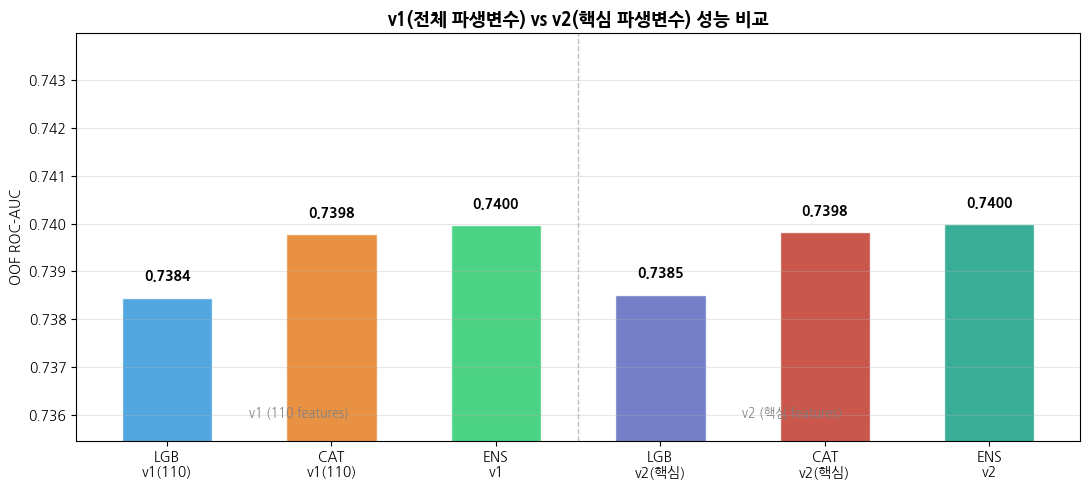


  === 결과 요약 ===
  LightGBM  v1: 0.7384  v2: 0.7385  diff: +0.0001
  CatBoost  v1: 0.7398  v2: 0.7398  diff: +0.0000
  앙상블    v1: 0.7400  v2: 0.7400  diff: +0.0000


In [62]:
# ── v2 앙상블 최적 가중치 탐색 ─────────────────────────────────────────
weights = np.arange(0.0, 1.05, 0.05)
blend_v2 = [roc_auc_score(y, (1-w)*oof_lgb_v2 + w*oof_cat_v2) for w in weights]
best_w_cat_v2 = weights[np.argmax(blend_v2)]
best_auc_v2   = max(blend_v2)
print(f'v2 최적 앙상블  w_cat={best_w_cat_v2:.2f}  AUC={best_auc_v2:.4f}')

# ── 전체 비교 시각화 ─────────────────────────────────────────────────────
labels = [
    'LGB\nv1(110)', 'CAT\nv1(110)', 'ENS\nv1',
    'LGB\nv2(핵심)', 'CAT\nv2(핵심)', 'ENS\nv2',
]
aucs = [
    roc_auc_score(y, oof_lgb), roc_auc_score(y, oof_cat), best_auc,
    auc_lgb_v2, auc_cat_v2, best_auc_v2,
]
colors = ['#3498db','#e67e22','#2ecc71','#5b6abf','#c0392b','#16a085']

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, aucs, color=colors, alpha=0.85, edgecolor='white', width=0.55)
for bar, a in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{a:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.ylim(min(aucs) - 0.003, max(aucs) + 0.004)
plt.axvline(2.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.text(0.8, min(aucs)-0.0025, 'v1 (110 features)', ha='center', fontsize=9, color='gray')
plt.text(3.8, min(aucs)-0.0025, 'v2 (핵심 features)', ha='center', fontsize=9, color='gray')
plt.ylabel('OOF ROC-AUC')
plt.title('v1(전체 파생변수) vs v2(핵심 파생변수) 성능 비교', fontweight='bold', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n  === 결과 요약 ===')
print(f'  LightGBM  v1: {roc_auc_score(y, oof_lgb):.4f}  v2: {auc_lgb_v2:.4f}  diff: {auc_lgb_v2 - roc_auc_score(y, oof_lgb):+.4f}')
print(f'  CatBoost  v1: {roc_auc_score(y, oof_cat):.4f}  v2: {auc_cat_v2:.4f}  diff: {auc_cat_v2 - roc_auc_score(y, oof_cat):+.4f}')
print(f'  앙상블    v1: {best_auc:.4f}  v2: {best_auc_v2:.4f}  diff: {best_auc_v2 - best_auc:+.4f}')


In [63]:
# 실험 로그 출력 (노트북 맨 앞 표 업데이트용 참고)
rows = [
    ('exp3', 'XGBoost',                    'v1 (110개)', 'max_depth=6, lr=0.05',            0.7391, ''),
    ('exp4', 'LightGBM',                   'v1 (110개)', 'num_leaves=127, lr=0.05',          roc_auc_score(y, oof_lgb), ''),
    ('exp5', 'CatBoost',                   'v1 (110개)', 'depth=6, lr=0.05',                 roc_auc_score(y, oof_cat), ''),
    ('exp6', 'CatBoost × LightGBM (ENS)',  'v1 (110개)', f'w_cat={best_w_cat:.2f}',          best_auc, 'v1 best'),
    ('exp7', 'LightGBM',                   'v2 (핵심 7개)', 'num_leaves=127, lr=0.05',       auc_lgb_v2, ''),
    ('exp8', 'CatBoost',                   'v2 (핵심 7개)', 'depth=6, lr=0.05',              auc_cat_v2, ''),
    ('exp9', 'CatBoost × LightGBM (ENS)', 'v2 (핵심 7개)', f'w_cat={best_w_cat_v2:.2f}',    best_auc_v2, ''),
]
print(f'{"실험":<6} {"모델":<30} {"FE":<14} {"파라미터":<26} {"OOF AUC":<10} {"비고"}')
print('-' * 100)
for r in rows:
    marker = ' ★' if r[4] == max(x[4] for x in rows) else ''
    print(f'{r[0]:<6} {r[1]:<30} {r[2]:<14} {r[3]:<26} {r[4]:.4f}    {r[5]}{marker}')


실험     모델                             FE             파라미터                       OOF AUC    비고
----------------------------------------------------------------------------------------------------
exp3   XGBoost                        v1 (110개)      max_depth=6, lr=0.05       0.7391    
exp4   LightGBM                       v1 (110개)      num_leaves=127, lr=0.05    0.7384    
exp5   CatBoost                       v1 (110개)      depth=6, lr=0.05           0.7398    
exp6   CatBoost × LightGBM (ENS)      v1 (110개)      w_cat=0.75                 0.7400    v1 best
exp7   LightGBM                       v2 (핵심 7개)     num_leaves=127, lr=0.05    0.7385    
exp8   CatBoost                       v2 (핵심 7개)     depth=6, lr=0.05           0.7398    
exp9   CatBoost × LightGBM (ENS)      v2 (핵심 7개)     w_cat=0.75                 0.7400     ★
